In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from src.constants.data_transformation_constant import *
import matplotlib.pyplot as plt

https://github.com/rakshithvasudev/Home-Credit-Default-Risk/blob/master/EDA/Exploratory%20Data%20Analysis%20-%20Application%20Train.ipynb

In [2]:
df = pd.read_csv(r'D:\home loan credit risk\artifact\interim\main_df_transformed.csv',dtype=APPLICATION_DATA_DTYPES_REDUCE)

In [6]:
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='float')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 261 entries, SK_ID_CURR to WORST_DPD_DEF_CREDIT_96M
dtypes: float32(186), float64(21), int32(7), int64(3), int8(28), object(16)
memory usage: 328.5+ MB


In [5]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,WORST_DPD_CREDIT_72M,WORST_DPD_CREDIT_96M,WORST_DPD_DEF_CREDIT_3M,WORST_DPD_DEF_CREDIT_6M,WORST_DPD_DEF_CREDIT_9M,WORST_DPD_DEF_CREDIT_12M,WORST_DPD_DEF_CREDIT_24M,WORST_DPD_DEF_CREDIT_36M,WORST_DPD_DEF_CREDIT_72M,WORST_DPD_DEF_CREDIT_96M
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0,-99999.0


In [4]:
df.duplicated().sum()

np.int64(0)

##### Credit Default Rate

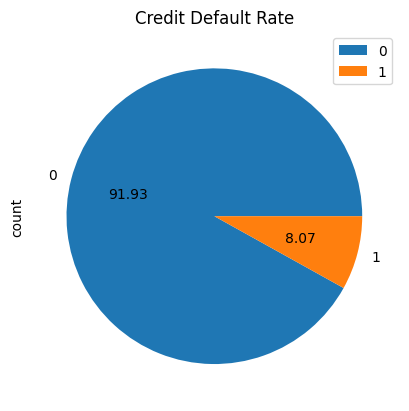

In [5]:
df['TARGET'].value_counts().plot(kind='pie',autopct='%0.2f',legend=True,title='Credit Default Rate')
plt.show()

##### Distribution of the LOANS

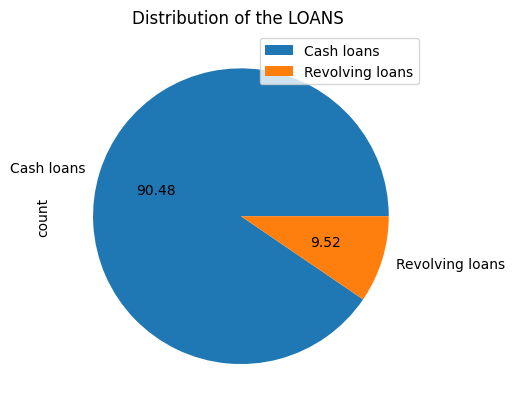

In [6]:
df['NAME_CONTRACT_TYPE'].value_counts().plot(kind='pie',autopct='%0.2f',legend=True,title='Distribution of the LOANS ')
plt.show()

##### Gender Analysis

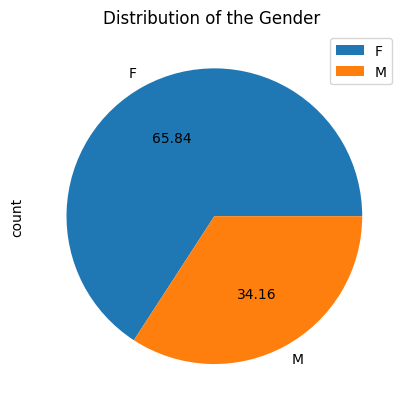

In [7]:
df['CODE_GENDER'].value_counts().plot(kind='pie',autopct='%0.2f',legend=True,title='Distribution of the Gender ')
plt.show()

In [8]:
code_gender = pd.crosstab(df['CODE_GENDER'],df['TARGET']).values[:,1] / pd.crosstab(df['CODE_GENDER'],df['TARGET']).values.sum(axis=1)
data_temp = {
    'CODE_GENDER':['F','M'],
    'TARGET':code_gender,
}
pd.DataFrame(data_temp)


,CODE_GENDER,TARGET
0,F,0.069993
1,M,0.101419


* The default rate among male applicants ~10.14% is higher than  female applicants ~6.99

##### NAME_CONTRACT_TYPE Analysis

In [9]:
pd.crosstab(df['NAME_CONTRACT_TYPE'],df['TARGET'])

TARGET,0,1
NAME_CONTRACT_TYPE,,
Cash loans,255011,23221
Revolving loans,27675,1604


In [10]:
loans_type = pd.crosstab(df['NAME_CONTRACT_TYPE'],df['TARGET']).values[:,1] / pd.crosstab(df['NAME_CONTRACT_TYPE'],df['TARGET']).values.sum(axis=1)
loans_type


array([0.08345913, 0.05478329])

* The default rate among NAME_CONTRACT_TYPE Cash loans  applicants is  ~8.30% is higher than Revolving loans  applicants ~5.47

##### FLAG_OWN_CAR Analysis

In [11]:
pd.crosstab(df['FLAG_OWN_CAR'],df['TARGET'])

TARGET,0,1
FLAG_OWN_CAR,,
N,185675,17249
Y,97011,7576


In [12]:
own_car = pd.crosstab(df['FLAG_OWN_CAR'],df['TARGET']).values[:,1] / pd.crosstab(df['FLAG_OWN_CAR'],df['TARGET']).values.sum(axis=1)
data_temp = {
    'CODE_GENDER':['N','Y'],
    'TARGET':own_car,
}
pd.DataFrame(data_temp)


,CODE_GENDER,TARGET
0,N,0.085002
1,Y,0.072437


* The default rate among FLAG_OWN_CAR N applicants ~8.50% is higher than FLAG_OWN_CAR Y applicants ~7.24

##### FLAG_OWN_REALTY Analysis

In [13]:
pd.crosstab(df['FLAG_OWN_REALTY'],df['TARGET'])

TARGET,0,1
FLAG_OWN_REALTY,,
N,86357,7842
Y,196329,16983


In [14]:
own_realty = pd.crosstab(df['FLAG_OWN_REALTY'],df['TARGET']).values[:,1] / pd.crosstab(df['FLAG_OWN_REALTY'],df['TARGET']).values.sum(axis=1)
data_temp = {
    'CODE_GENDER':['N','Y'],
    'TARGET':own_realty,
}
pd.DataFrame(data_temp)


,CODE_GENDER,TARGET
0,N,0.083249
1,Y,0.079616


* The default rate among FLAG_OWN_REALTY N  applicants ~8.3% is higher than FLAG_OWN_CAR  Y applicants ~7.96

##### CNT_CHILDREN analysis

In [15]:
pd.crosstab(df['CNT_CHILDREN'],df['TARGET'])

TARGET,0,1
CNT_CHILDREN,,
0,198762,16609
1,55665,5454
2,24416,2333
3,3359,358
4,374,55
5,77,7
6,15,6
7,7,0
8,2,0


In [16]:
cnt_children = pd.crosstab(df['CNT_CHILDREN'],df['TARGET']).values[:,1] / pd.crosstab(df['CNT_CHILDREN'],df['TARGET']).values.sum(axis=1)
cnt_children

array([0.07711809, 0.08923575, 0.08721821, 0.09631423, 0.12820513,
       0.08333333, 0.28571429, 0.        , 0.        , 1.        ,
       0.        , 1.        , 0.        , 0.        , 0.        ])

In [17]:
# grouping the 5+ children as 5 to avoid sparsity
df['DUMMY_CHILDREN']  = np.where(df['CNT_CHILDREN']>= 5,5,df['CNT_CHILDREN'] )

In [18]:
cnt_children = pd.crosstab(df['DUMMY_CHILDREN'],df['TARGET']).values[:,1] / pd.crosstab(df['DUMMY_CHILDREN'],df['TARGET']).values.sum(axis=1)
cnt_children


array([0.07711809, 0.08923575, 0.08721821, 0.09631423, 0.12820513,
       0.12698413])

*0 → 7.7%, 1 → 8.9%, 2 → 8.7%, 3 → 9.6%, 4 → 12.8%, 5+ → 12.7%* <br>
The default rate  increases with the number of children, indicates the borrower with more children have to spend for their children  so they might have the financial burden
 cnt about 5 + is rare so grouped as 5 to reduce data sparsity

##### AMT_INCOME_TOTAL Analysis

In [19]:
df['AMT_INCOME_TOTAL'].quantile(0.99)

np.float64(472500.0)

<Axes: xlabel='AMT_INCOME_TOTAL', ylabel='Density'>

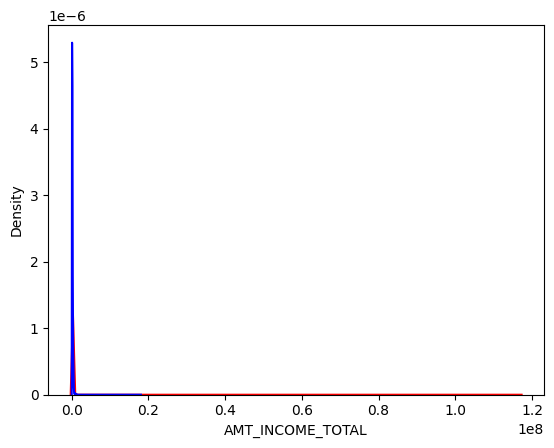

In [20]:
#sns.kdeplot(df['AMT_INCOME_TOTAL'])
filt = df['TARGET'] == 1
sns.kdeplot(df.loc[filt,'AMT_INCOME_TOTAL'],color='r')
filt = df['TARGET'] == 0
sns.kdeplot(df.loc[filt,'AMT_INCOME_TOTAL'],color='b')

* highly right skewed  distribution feature use transformation
* 99 % client have income less than 472500.0. and 1 % have extrene high income  being extreme outliers



##### AMT_CREDIT , AMT_ANNUITY AMT_GOODS_PRICE Analysis

<Axes: xlabel='AMT_CREDIT', ylabel='Density'>

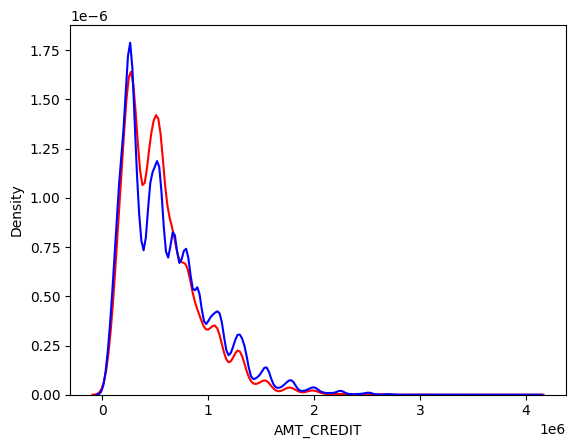

In [21]:
filt = df['TARGET'] == 1
sns.kdeplot(df.loc[filt,'AMT_CREDIT'],color='r')
filt = df['TARGET'] == 0
sns.kdeplot(df.loc[filt,'AMT_CREDIT'],color='b')

In [22]:
df['AMT_CREDIT'].quantile(0.80)

np.float64(900000.0)

In [23]:
df['AMT_CREDIT'].quantile(0.90)

np.float64(1133748.0)

* right skewed distribution 

<Axes: xlabel='AMT_ANNUITY', ylabel='Density'>

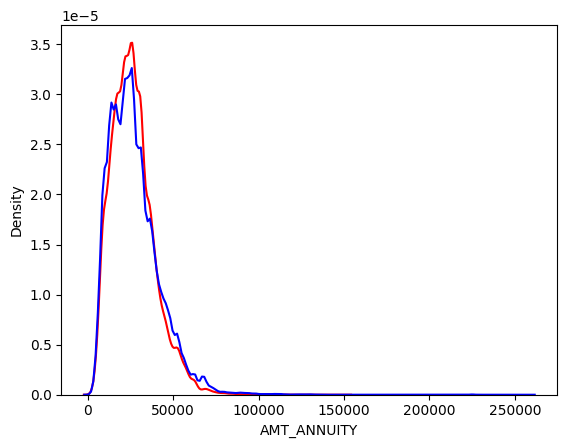

In [24]:
filt = df['TARGET'] == 1
sns.kdeplot(df.loc[filt,'AMT_ANNUITY'],color='r')
filt = df['TARGET'] == 0
sns.kdeplot(df.loc[filt,'AMT_ANNUITY'],color='b')

* right skewed distribution most of the client having the  0 - 50k as annuity  with long tail  exceding 200k



<Axes: xlabel='AMT_GOODS_PRICE', ylabel='Density'>

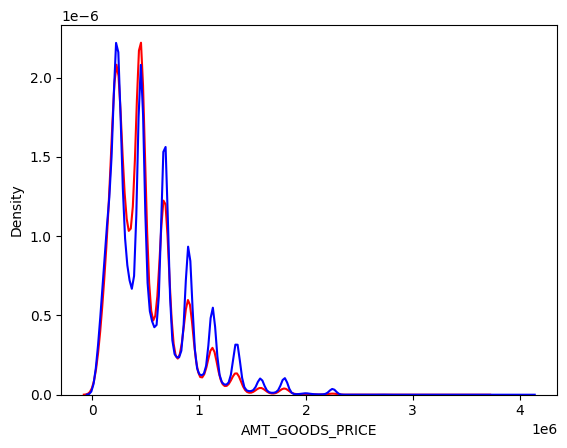

In [25]:
filt = df['TARGET'] == 1
sns.kdeplot(df.loc[filt,'AMT_GOODS_PRICE'],color='r')
filt = df['TARGET'] == 0
sns.kdeplot(df.loc[filt,'AMT_GOODS_PRICE'],color='b')

In [26]:
df['AMT_GOODS_PRICE'].quantile(0.85)

np.float64(900000.0)

In [27]:
df['AMT_GOODS_PRICE'].max()

np.float64(4050000.0)

* AMT_GOODS_PRICE has a right-skewed distribution  85% of clients purchasing goods worth less than ₹900,000, while a some clients have goods priced above ₹1,000,000, forming a long right tail.

##### NAME_TYPE_SUITE Analysis

<Axes: title={'center': 'Clients Type Suite Distribution'}, xlabel='NAME_TYPE_SUITE'>

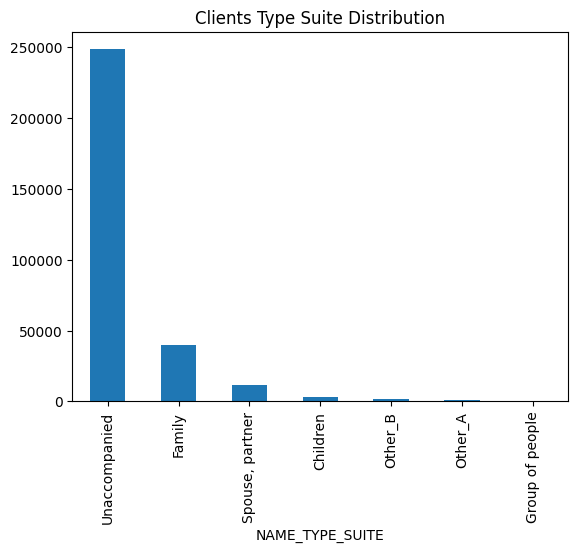

In [28]:
df['NAME_TYPE_SUITE'].value_counts().plot(kind='bar',title='Clients Type Suite Distribution')

In [29]:
type_suit = pd.crosstab(df['NAME_TYPE_SUITE'],df['TARGET']).values[:,1] / pd.crosstab(df['NAME_TYPE_SUITE'],df['TARGET']).values.sum(axis=1)
type_suit

array([0.07376798, 0.07494583, 0.08487085, 0.08775982, 0.09830508,
       0.07871592, 0.08183047])

In [30]:
pd.crosstab(df['NAME_TYPE_SUITE'],df['TARGET'])

TARGET,0,1
NAME_TYPE_SUITE,,
Children,3026,241
Family,37140,3009
Group of people,248,23
Other_A,790,76
Other_B,1596,174
"Spouse, partner",10475,895
Unaccompanied,228189,20337


The default rates  NAME_TYPE_SUITE. Clients living with Other_B (9.8%) or Other_A (8.8%) have  higher default rates, while those living with Children (7.4%) or Family (7.5%) have lower default rates. The majority of clients are Unaccompanied, with a default rate of 8.2%.

##### NAME_INCOME_TYPE Analysis

<Axes: title={'center': 'Clients Type income type Distribution'}, xlabel='NAME_INCOME_TYPE'>

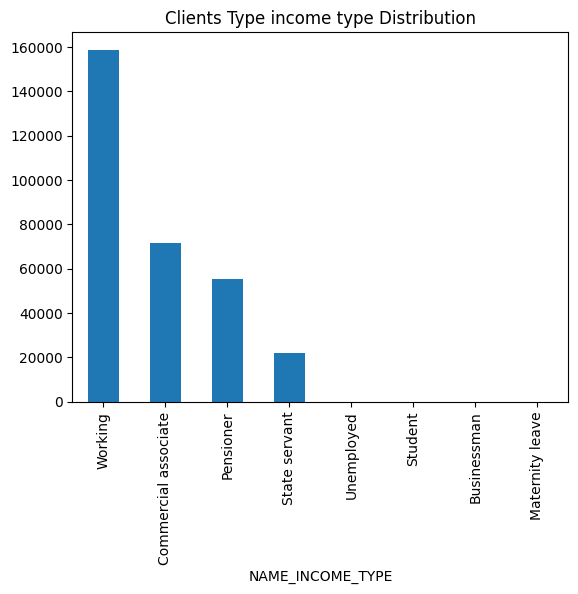

In [31]:
df['NAME_INCOME_TYPE'].value_counts().plot(kind='bar',title='Clients Type income type Distribution')

In [32]:
pd.crosstab(df['NAME_INCOME_TYPE'],df['TARGET'])

TARGET,0,1
NAME_INCOME_TYPE,,
Businessman,10,0
Commercial associate,66257,5360
Maternity leave,3,2
Pensioner,52380,2982
State servant,20454,1249
Student,18,0
Unemployed,14,8
Working,143550,15224


In [33]:
df.groupby(by='NAME_INCOME_TYPE')['TARGET'].mean()

NAME_INCOME_TYPE
Businessman             0.000000
Commercial associate    0.074843
Maternity leave         0.400000
Pensioner               0.053864
State servant           0.057550
Student                 0.000000
Unemployed              0.363636
Working                 0.095885
Name: TARGET, dtype: float64

* student+ unemployed combine 
* working class have higheest number of defaulters

##### NAME_EDUCATION_TYPE Analysis

In [34]:
pd.crosstab(df['NAME_EDUCATION_TYPE'],df['TARGET'])

TARGET,0,1
NAME_EDUCATION_TYPE,,
Academic degree,161,3
Higher education,70854,4009
Incomplete higher,9405,872
Lower secondary,3399,417
Secondary education,198867,19524


In [35]:
df.groupby(by='NAME_EDUCATION_TYPE')['TARGET'].mean()

NAME_EDUCATION_TYPE
Academic degree        0.018293
Higher education       0.053551
Incomplete higher      0.084850
Lower secondary        0.109277
Secondary education    0.089399
Name: TARGET, dtype: float64

* Default rate increases as education level decreases.
* People with academic/higher education default less.
* People with lower/secondary education default more.

##### NAME_HOUSING_TYPE Analysis

In [36]:
df.groupby(by='NAME_HOUSING_TYPE')['TARGET'].mean()

NAME_HOUSING_TYPE
Co-op apartment        0.079323
Municipal apartment    0.085397
Office apartment       0.065724
Owned                  0.077957
Rented apartment       0.123131
With parents           0.116981
Name: TARGET, dtype: float64

* The default rate among  applicants  living in rented apartments is ~12.31%  and with parents 
is ~11.69  higher than other applicants.

##### CNT_FAM_MEMBERS Analysis

In [37]:
df['DUMMY_FAM_MEMBERS'] = np.where(df['CNT_FAM_MEMBERS']>=7,7,df['CNT_FAM_MEMBERS'])

In [38]:
pd.crosstab(df['DUMMY_FAM_MEMBERS'],df['TARGET'])

TARGET,0,1
DUMMY_FAM_MEMBERS,,
1.0,62172,5675
2.0,146348,12009
3.0,47993,4608
4.0,22561,2136
5.0,3151,327
6.0,353,55
7.0,106,15


In [39]:
cnt_fam = pd.crosstab(df['DUMMY_FAM_MEMBERS'],df['TARGET']).values[:,1] / pd.crosstab(df['DUMMY_FAM_MEMBERS'],df['TARGET']).values.sum(axis=1)
cnt_fam

array([0.08364408, 0.07583498, 0.0876029 , 0.08648824, 0.09401955,
       0.13480392, 0.12396694])

* large families with the 5+ members  have the highest default rate 9.4- 13.4. suggesting higher risk

##### REGION_RATING_CLIENT Analysis

In [40]:
pd.crosstab(df['REGION_RATING_CLIENT'],df['TARGET'])

TARGET,0,1
REGION_RATING_CLIENT,,
1,30645,1552
2,209077,17907
3,42964,5366


In [41]:
region_rating = pd.crosstab(df['REGION_RATING_CLIENT'],df['TARGET']).values[:,1] / pd.crosstab(df['REGION_RATING_CLIENT'],df['TARGET']).values.sum(axis=1)
region_rating

array([0.04820325, 0.07889102, 0.11102835])

* REGION_RATING_CLIENT increases from 1 to 3, the default rate also increases.
and 3 rating with the risk 11%


##### REGION_RATING_CLIENT_W_CITY

In [42]:
pd.crosstab(df['REGION_RATING_CLIENT_W_CITY'],df['TARGET'])

TARGET,0,1
REGION_RATING_CLIENT_W_CITY,,
1,32513,1654
2,211314,18170
3,38859,5001


In [43]:
df.groupby('REGION_RATING_CLIENT_W_CITY')['TARGET'].mean()


REGION_RATING_CLIENT_W_CITY
1    0.048409
2    0.079178
3    0.114022
Name: TARGET, dtype: float64

* REGION_RATING_CLIENT_W_CITY increases from 1 to 3, the default rate also increases.

In [44]:
df.groupby('REG_CITY_NOT_LIVE_CITY')['TARGET'].mean()


REG_CITY_NOT_LIVE_CITY
0    0.077207
1    0.122260
Name: TARGET, dtype: float64

* Clients living in a different city than their registered contact addres city have a higher probability of default.12.2% vs 7.7%. the difference is noticeable

In [45]:
df.groupby('ORGANIZATION_TYPE')['TARGET'].mean().sort_values(ascending=False)

ORGANIZATION_TYPE
Transport: type 3         0.157540
Industry: type 13         0.134328
Industry: type 8          0.125000
Restaurant                0.117062
Construction              0.116798
Cleaning                  0.111538
Industry: type 1          0.110683
Industry: type 3          0.106162
Realtor                   0.106061
Agriculture               0.104727
Trade: type 3             0.103379
Self-employed             0.101739
Industry: type 4          0.101482
Security                  0.099784
Trade: type 7             0.094496
Business Entity Type 3    0.092996
Transport: type 4         0.092812
Mobile                    0.091483
Trade: type 1             0.089080
Industry: type 11         0.086538
Business Entity Type 2    0.085284
Postal                    0.084376
Advertising               0.081585
Business Entity Type 1    0.081384
Industry: type 7          0.080337
Housing                   0.079446
Legal Services            0.078689
Transport: type 2         0.078040
Ot

* the feature ORGANIZATION_TYPE have 50+ unique categories indicating high cardinity.
* the industries are correlated with credit risk.
* the people having stable job like medicine ,services,insurance they default less than the people who work in industrial sector like transport,construction.

##### EXT_SOURCE_1 ,EXT_SOURCE_2, EXT_SOURCE_3 External source score analysis

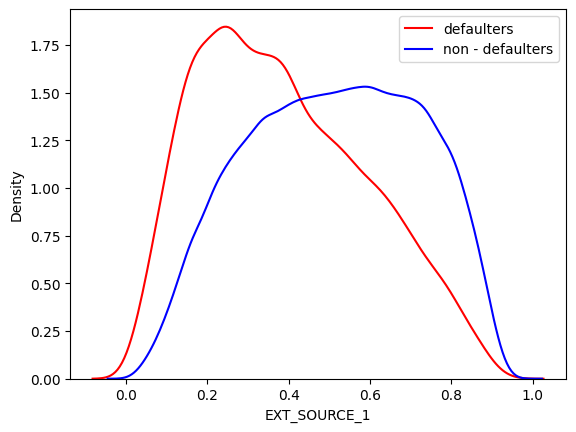

In [46]:
filt = df['TARGET'] == 1
sns.kdeplot(df.loc[filt,'EXT_SOURCE_1'],color='r',label='defaulters')
filt = df['TARGET'] == 0
sns.kdeplot(df.loc[filt,'EXT_SOURCE_1'],color='b',label='non - defaulters')
plt.legend()
plt.show()

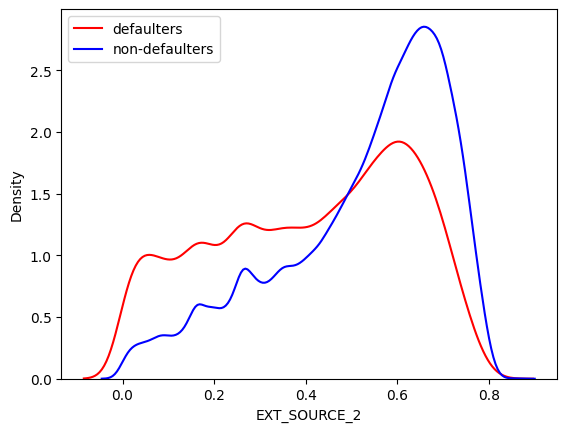

In [47]:
filt = df['TARGET'] == 1
sns.kdeplot(df.loc[filt,'EXT_SOURCE_2'],color='r',label='defaulters')
filt = df['TARGET'] == 0
sns.kdeplot(df.loc[filt,'EXT_SOURCE_2'],color='b',label='non-defaulters')
plt.legend()
plt.show()

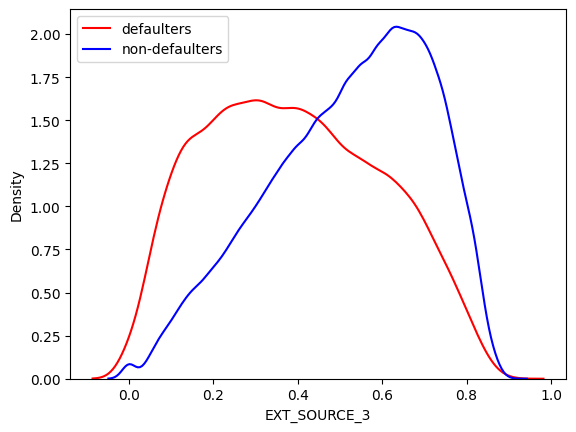

In [48]:
filt = df['TARGET'] == 1
sns.kdeplot(df.loc[filt,'EXT_SOURCE_3'],color='r',label='defaulters')
filt = df['TARGET'] == 0
sns.kdeplot(df.loc[filt,'EXT_SOURCE_3'],color='b',label='non-defaulters')
plt.legend()
plt.show()


* In the variables  EXT_SOURCE_1 , EXT_SOURCE_2, EXT_SOURCE_3  the people with score below the 
~ 0.43 tends to default more frequently. the lower external source score associated with higher credit risk
* these feature are highly correlated with the target variable

##### EMERGENCYSTATE_MODE Analysis

In [49]:
df.groupby(by=df['EMERGENCYSTATE_MODE'])['TARGET'].mean()

EMERGENCYSTATE_MODE
No     0.069649
Yes    0.095790
Name: TARGET, dtype: float64

In [50]:
df['EMERGENCYSTATE_MODE'].isnull().sum() / df['EMERGENCYSTATE_MODE'].shape[0]

np.float64(0.47398304450897694)

*  Applicants with EMERGENCYSTATE_MODE = Yes have a slightly higher default rate (9.6%) compared to those with No (7.0%). the feature contains ~47% null values


##### Geographical features

APARTMENTS_AVG	BASEMENTAREA_AVG	YEARS_BEGINEXPLUATATION_AVG	YEARS_BUILD_AVG	COMMONAREA_AVG	ELEVATORS_AVG	ENTRANCES_AVG	FLOORSMAX_AVG	FLOORSMIN_AVG	LANDAREA_AVG	LIVINGAPARTMENTS_AVG	LIVINGAREA_AVG	NONLIVINGAPARTMENTS_AVG	NONLIVINGAREA_AVG

APARTMENTS_MODE	BASEMENTAREA_MODE	YEARS_BEGINEXPLUATATION_MODE	YEARS_BUILD_MODE	COMMONAREA_MODE	ELEVATORS_MODE	ENTRANCES_MODE	FLOORSMAX_MODE	FLOORSMIN_MODE	LANDAREA_MODE	LIVINGAPARTMENTS_MODE	LIVINGAREA_MODE	NONLIVINGAPARTMENTS_MODE	NONLIVINGAREA_MODE
	
APARTMENTS_MEDI	BASEMENTAREA_MEDI	YEARS_BEGINEXPLUATATION_MEDI	YEARS_BUILD_MEDI	COMMONAREA_MEDI	ELEVATORS_MEDI	ENTRANCES_MEDI	FLOORSMAX_MEDI	FLOORSMIN_MEDI	LANDAREA_MEDI	LIVINGAPARTMENTS_MEDI	LIVINGAREA_MEDI	NONLIVINGAPARTMENTS_MEDI	NONLIVINGAREA_MEDI	FONDKAPREMONT_MODE	HOUSETYPE_MODE	TOTALAREA_MODE	

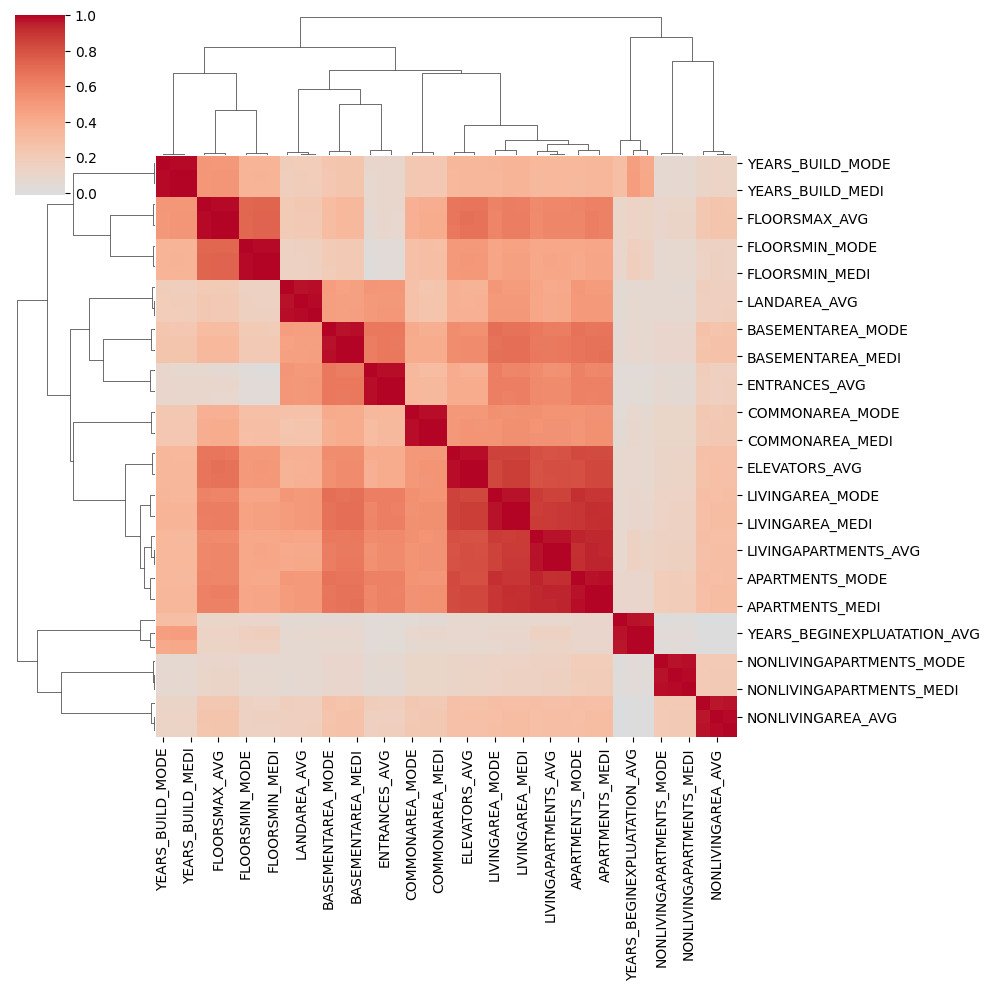

In [51]:
house_features = [
    'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG',
    'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG',
    'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG',
    'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG',    'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE',
    'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE',
    'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE',
    'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE',    'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI',
    'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI',
    'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI',
    'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI',

]
sns.clustermap(df[house_features].corr(),cmap="coolwarm", center=0)

* since the mean median mode are aggregated and normalized from dataset. since  the distribution or nature of this dataset is Unknown hence using the median will be most appropiate choice. because  median is robust to outlier and it provides more stable central tendancy representation for skewed data  
* and we cant use all the feature because they are collinear to each other so we will use only median for building model so it will also reduce dimensionality of data


create a missing indcator feature for the missing geographic values

<Axes: title={'center': 'Default by house type'}, xlabel='HOUSETYPE_MODE'>

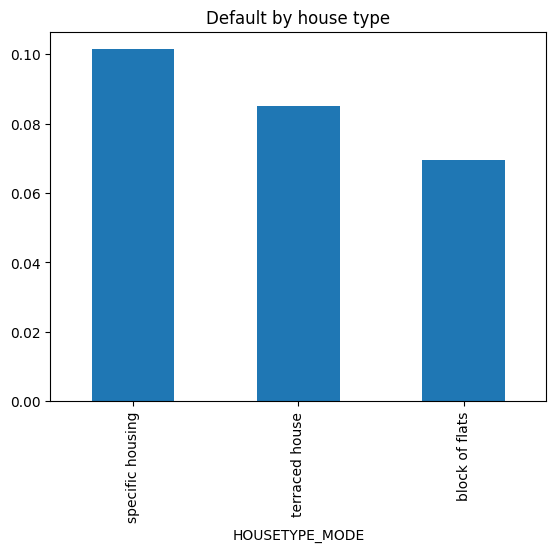

In [52]:
df.groupby(df['HOUSETYPE_MODE'])['TARGET'].mean().sort_values(ascending=False).plot(kind='bar',title='Default by house type')

* applicants living in blocks of flats have lowest default rate ~(6.9)% , while people living in specific housing have the highest default rate ~(10.1)% it shows there is relation of the house types 

In [53]:
df.groupby(df['WALLSMATERIAL_MODE'])['TARGET'].mean()

WALLSMATERIAL_MODE
Block           0.070247
Mixed           0.075348
Monolithic      0.047218
Others          0.083077
Panel           0.063477
Stone, brick    0.074057
Wooden          0.096979
Name: TARGET, dtype: float64

WALLSMATERIAL_MODE shows very small differences in default rates across categories. does not provide strong discriminatory power for predicting credit risk. but still check feature importance and keep if it adds value otherwise remove it

In [54]:
df.groupby(by=df['EMERGENCYSTATE_MODE'])['TARGET'].mean()

EMERGENCYSTATE_MODE
No     0.069649
Yes    0.095790
Name: TARGET, dtype: float64

Clients with EMERGENCYSTATE_MODE = Yes have a higher default rate compared to those with No by ~3% it is less still we have to check iv or woe for this feature

##### social circle features

In [55]:
df.groupby(df['OBS_60_CNT_SOCIAL_CIRCLE'])['TARGET'].mean().sort_values(ascending=False)

OBS_60_CNT_SOCIAL_CIRCLE
29.0     0.500000
19.0     0.159091
23.0     0.153846
13.0     0.102244
22.0     0.100000
14.0     0.096639
17.0     0.095890
11.0     0.094385
25.0     0.090909
10.0     0.090637
7.0      0.090009
6.0      0.088990
4.0      0.088341
12.0     0.087097
9.0      0.086269
5.0      0.084328
8.0      0.083160
3.0      0.082612
2.0      0.082241
1.0      0.079681
0.0      0.079075
15.0     0.066265
16.0     0.065693
18.0     0.040816
21.0     0.035714
24.0     0.000000
20.0     0.000000
27.0     0.000000
26.0     0.000000
28.0     0.000000
30.0     0.000000
47.0     0.000000
344.0    0.000000
Name: TARGET, dtype: float64

In [56]:
df.groupby(df['OBS_30_CNT_SOCIAL_CIRCLE'])['TARGET'].mean().sort_values(ascending=False)

OBS_30_CNT_SOCIAL_CIRCLE
30.0     0.500000
22.0     0.136364
23.0     0.133333
19.0     0.113636
13.0     0.107056
20.0     0.100000
11.0     0.095070
7.0      0.093622
12.0     0.093558
14.0     0.093023
25.0     0.090909
4.0      0.088242
10.0     0.087936
6.0      0.087556
9.0      0.084873
5.0      0.083429
8.0      0.082912
2.0      0.082461
3.0      0.082423
1.0      0.079843
0.0      0.079007
17.0     0.068182
16.0     0.067669
15.0     0.066265
18.0     0.043478
24.0     0.000000
21.0     0.000000
27.0     0.000000
26.0     0.000000
28.0     0.000000
29.0     0.000000
47.0     0.000000
348.0    0.000000
Name: TARGET, dtype: float64

* as the OBS_30_CNT_SOCIAL_CIRCLE and OBS_30_CNT_SOCIAL_CIRCLE value increses more than 10 the default probability of this client increases
* higher number of people suronding of the client with payment issue : higher risk

<Axes: title={'center': 'DEF_30_CNT_SOCIAL_CIRCLE Default'}, xlabel='DEF_30_CNT_SOCIAL_CIRCLE'>

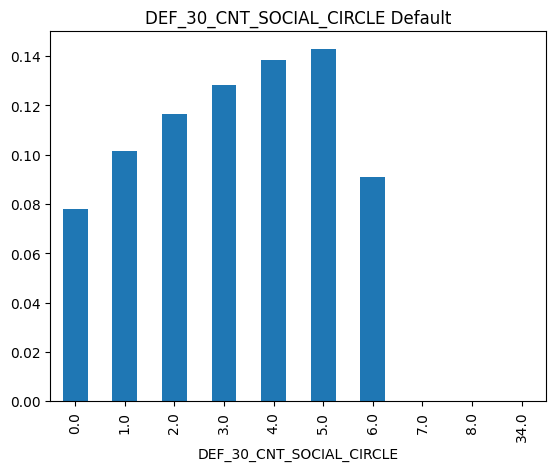

In [57]:
df.groupby(df['DEF_30_CNT_SOCIAL_CIRCLE'])['TARGET'].mean().plot(kind='bar',title='DEF_30_CNT_SOCIAL_CIRCLE Default')

<Axes: title={'center': 'DEF_60_CNT_SOCIAL_CIRCLE Default'}, xlabel='DEF_60_CNT_SOCIAL_CIRCLE'>

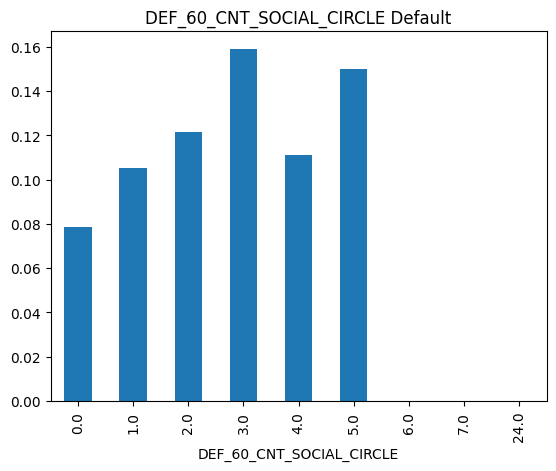

In [58]:
df.groupby(df['DEF_60_CNT_SOCIAL_CIRCLE'])['TARGET'].mean().plot(kind='bar',title='DEF_60_CNT_SOCIAL_CIRCLE Default')

* When DEF_60_CNT_SOCIAL_CIRCLE and DEF_30_CNT_SOCIAL_CIRCLE increase from 0 to 5, the default rate increases consistently. that suggest if more people in your circle have defaulted. most likly the client will also default


<Axes: xlabel='DAYS_LAST_PHONE_CHANGE', ylabel='Density'>

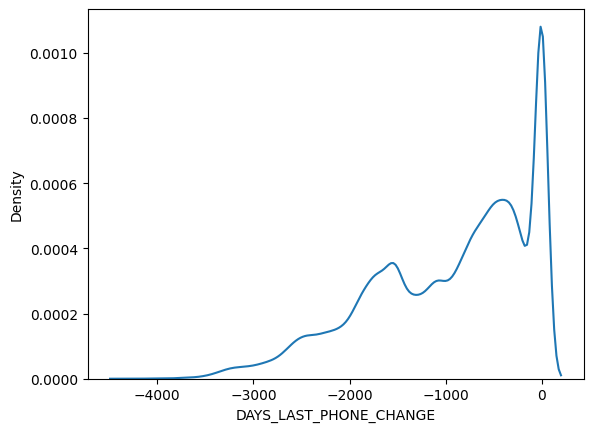

In [59]:
sns.kdeplot(df['DAYS_LAST_PHONE_CHANGE'])

* left skewed distribution need to use the transformation 

##### Documents Features Analysis

In [60]:
for i in range(2,22):
    print(df.groupby(df[f'FLAG_DOCUMENT_{i}'])['TARGET'].mean())
    print(df[f'FLAG_DOCUMENT_{i}'].value_counts())
    print(' ')


FLAG_DOCUMENT_2
0    0.080719
1    0.307692
Name: TARGET, dtype: float64
FLAG_DOCUMENT_2
0    307498
1        13
Name: count, dtype: int64
 
FLAG_DOCUMENT_3
0    0.061825
1    0.088449
Name: TARGET, dtype: float64
FLAG_DOCUMENT_3
1    218340
0     89171
Name: count, dtype: int64
 
FLAG_DOCUMENT_4
0    0.080735
1    0.000000
Name: TARGET, dtype: float64
FLAG_DOCUMENT_4
0    307486
1        25
Name: count, dtype: int64
 
FLAG_DOCUMENT_5
0    0.080739
1    0.080034
Name: TARGET, dtype: float64
FLAG_DOCUMENT_5
0    302863
1      4648
Name: count, dtype: int64
 
FLAG_DOCUMENT_6
0    0.083150
1    0.055654
Name: TARGET, dtype: float64
FLAG_DOCUMENT_6
0    280433
1     27078
Name: count, dtype: int64
 
FLAG_DOCUMENT_7
0    0.080735
1    0.050847
Name: TARGET, dtype: float64
FLAG_DOCUMENT_7
0    307452
1        59
Name: count, dtype: int64
 
FLAG_DOCUMENT_8
0    0.081381
1    0.073370
Name: TARGET, dtype: float64
FLAG_DOCUMENT_8
0    282487
1     25024
Name: count, dtype: int64
 
FLAG_DOCUMENT

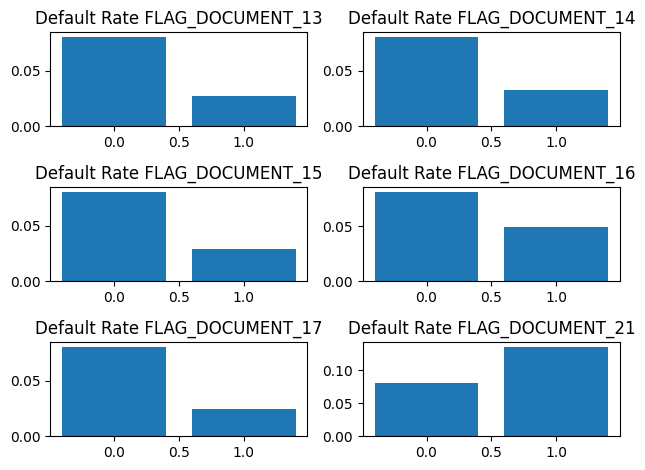

In [61]:
features = [
    "FLAG_DOCUMENT_13",
    "FLAG_DOCUMENT_14",
    "FLAG_DOCUMENT_15",
    "FLAG_DOCUMENT_16",
    "FLAG_DOCUMENT_17",
    "FLAG_DOCUMENT_21"
    ]
df[features]

for i, feature in enumerate(features):
    plt.subplot(3,2,i+1)
    index = df.groupby(by=df[feature])['TARGET'].mean().index.values
    values = df.groupby(by=df[feature])['TARGET'].mean().values
    plt.bar(index,values)
    plt.title('Default Rate '+feature)
plt.tight_layout()
plt.show()

* not enough sample size misleading 2,4,10,12 for this documents need to remove or take care of this 
* the people who submitted this(value=1) documents 13,14,15,16,17,21 have significantlly lower credit default rate then those who aren't submitted (value=0)


In [62]:
flag_document_features = [
    "FLAG_DOCUMENT_2",
    "FLAG_DOCUMENT_4",
    "FLAG_DOCUMENT_10",
    "FLAG_DOCUMENT_12",
    "FLAG_DOCUMENT_3",
    "FLAG_DOCUMENT_5",
    "FLAG_DOCUMENT_6",
    "FLAG_DOCUMENT_7",
    "FLAG_DOCUMENT_8",
    "FLAG_DOCUMENT_9",
    "FLAG_DOCUMENT_11",
    "FLAG_DOCUMENT_18",
    "FLAG_DOCUMENT_19",
    "FLAG_DOCUMENT_20",
]
df['CNT_OTHER_DOCUMENT_PROVIDED'] = df[flag_document_features].sum(axis=1)

<Axes: title={'center': 'Number of other documetns provided'}, xlabel='CNT_OTHER_DOCUMENT_PROVIDED'>

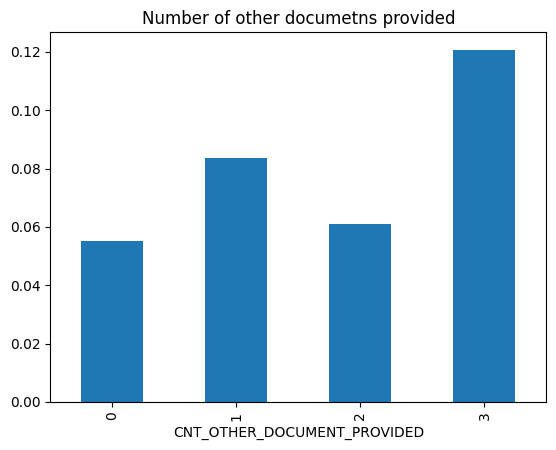

In [63]:
df.groupby(by=df['CNT_OTHER_DOCUMENT_PROVIDED'])['TARGET'].mean().plot(kind='bar',title='Number of other documetns provided')

* merging the weak predictive documents feature to create CNT_OTHER_DOCUMENT_PROVIDED.
* the applicants who submitted documents more than 2 have high default rate ~12. and the applicants who submitted documents 0-2 have default rate bet  ~(5-8)% .
* create feature for the model



##### BUREAU REQ FEATURES ANALYSIS

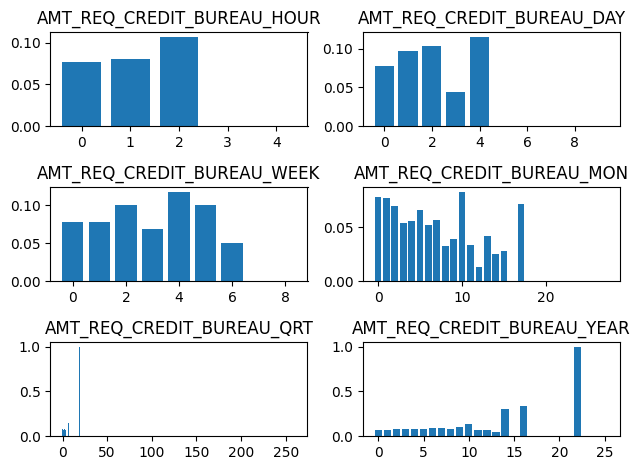

In [64]:
feature_list = [
    "AMT_REQ_CREDIT_BUREAU_HOUR",
    "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR",
]


for idx,feature in enumerate(feature_list):
    plt.subplot(3,2,idx+1)
    index = df.groupby(by=feature)['TARGET'].mean().index.values
    values = df.groupby(by=feature)['TARGET'].mean().values
    plt.bar(index,values)
    plt.title(feature)


plt.subplots_adjust(hspace=0.6, wspace=0.3)  

plt.tight_layout()
plt.show()


In [65]:
df['AMT_REQ_CREDIT_BUREAU_QRT'].quantile(0.99)

np.float32(2.0)

In [66]:
df['AMT_REQ_CREDIT_BUREAU_QRT'].unique()

array([  0.,  nan,   1.,   2.,   4.,   3.,   8.,   5.,   6.,   7., 261.,
        19.], dtype=float32)

<Axes: xlabel='DUMMY_AMT_QTR'>

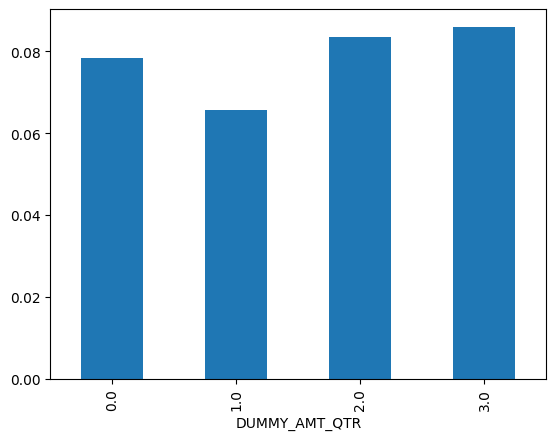

In [67]:
df['DUMMY_AMT_QTR'] = np.where(df['AMT_REQ_CREDIT_BUREAU_QRT'] > 2,3,df['AMT_REQ_CREDIT_BUREAU_QRT'])
df.groupby(by=df['DUMMY_AMT_QTR'])['TARGET'].mean().plot(kind='bar')

In [68]:
df['AMT_REQ_CREDIT_BUREAU_MON'].quantile(0.99)

np.float32(4.0)

<Axes: xlabel='DUMMY_AMT_MON'>

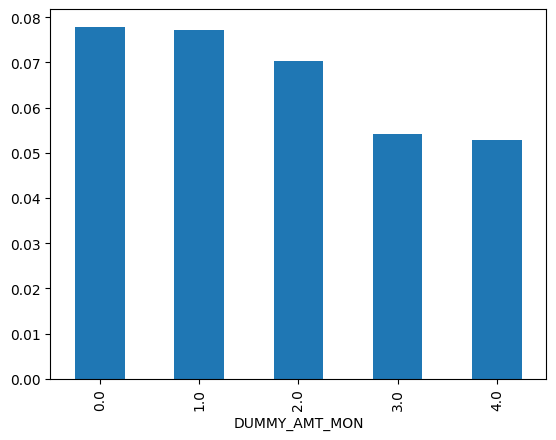

In [69]:
df['DUMMY_AMT_MON'] = np.where(df['AMT_REQ_CREDIT_BUREAU_MON'] > 4,4,df['AMT_REQ_CREDIT_BUREAU_MON'])
df.groupby(by=df['DUMMY_AMT_MON'])['TARGET'].mean().plot(kind='bar')

In [70]:
df['AMT_REQ_CREDIT_BUREAU_YEAR'].quantile(0.99)

np.float32(8.0)

<Axes: xlabel='DUMMY_AMT_YEAR'>

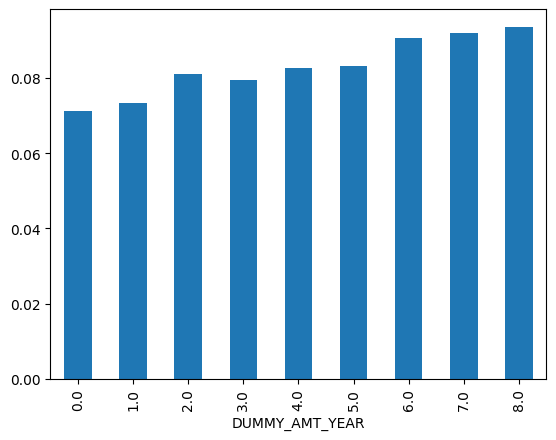

In [71]:
df['DUMMY_AMT_YEAR'] = np.where(df['AMT_REQ_CREDIT_BUREAU_YEAR'] > 8,8,df['AMT_REQ_CREDIT_BUREAU_YEAR'])
df.groupby(by=df['DUMMY_AMT_YEAR'])['TARGET'].mean().plot(kind='bar')

* more credit bureau enquiries (hour,day,week) is correlated with the higher default rate.
* there are some number in middile that shows low default due to less data availabel in  (hour,day,week) this feature.

* AMT_REQ_CREDIT_BUREAU_MON and AMT_REQ_CREDIT_BUREAU_QRT do not show a meaningful correlation with default, 99% of data lies between 0-4. values  are extremely rare so it cant be interpreted.
the pattern doesnt show any direct relation with the credit risk it doesnt seems like higher predictive power as the hour,day,week
* we will use   (hour,day,week and year) req feature to build model clipping year at 8 give some upward trend relation with default rate

##### YEARS AGE

<Axes: xlabel='YEARS_AGE', ylabel='Density'>

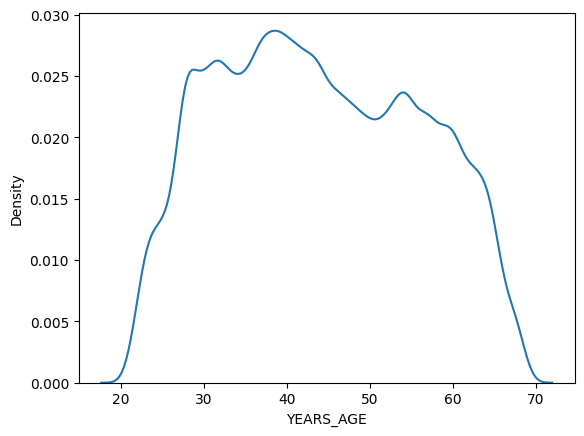

In [72]:
sns.kdeplot(df['YEARS_AGE'])

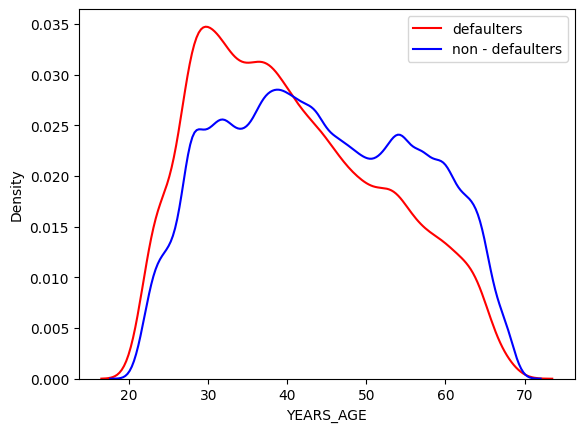

In [73]:
filt = df['TARGET'] == 1
sns.kdeplot(df.loc[filt,'YEARS_AGE'],color='r',label='defaulters')
filt = df['TARGET'] == 0
sns.kdeplot(df.loc[filt,'YEARS_AGE'],color='b',label='non - defaulters')
plt.legend()
plt.show()

* the YEARS_AGE like feature have normal like distribution
* the applicants ageD between (20-40) have more default rate a they are more likely to default compared to applicants with the age of 40-70 

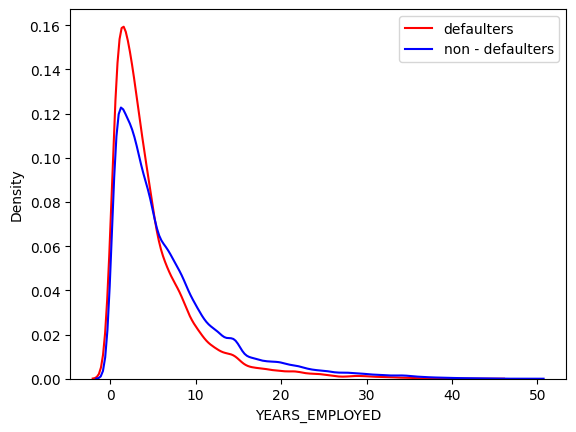

In [74]:
filt = df['TARGET'] == 1
sns.kdeplot(df.loc[filt,'YEARS_EMPLOYED'],color='r',label='defaulters')
filt = df['TARGET'] == 0
sns.kdeplot(df.loc[filt,'YEARS_EMPLOYED'],color='b',label='non - defaulters')
plt.legend()
plt.show()

* YEARS_EMPLOYED feature is right skewed. with most of the applicants having experience less than 10 years.
* this graphs shows the experience less than 7 years have more default rate. and the experience increases the default rate redce that suggest the longer employment experience have less credit risk

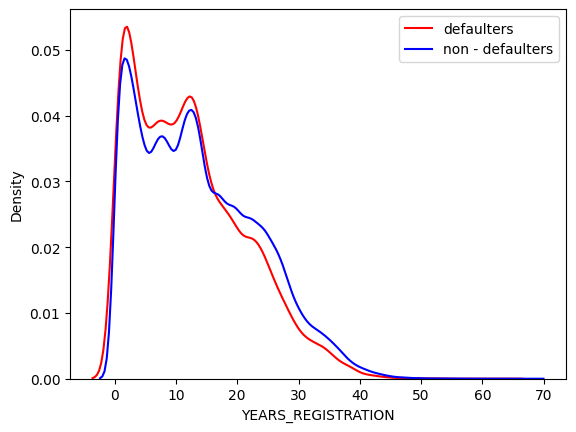

In [75]:
filt = df['TARGET'] == 1
sns.kdeplot(df.loc[filt,'YEARS_REGISTRATION'],color='r',label='defaulters')
filt = df['TARGET'] == 0
sns.kdeplot(df.loc[filt,'YEARS_REGISTRATION'],color='b',label='non - defaulters')
plt.legend()
plt.show()

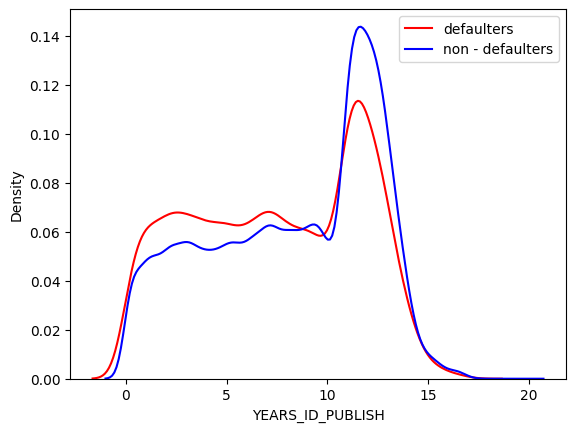

In [76]:
filt = df['TARGET'] == 1
sns.kdeplot(df.loc[filt,'YEARS_ID_PUBLISH'],color='r',label='defaulters')
filt = df['TARGET'] == 0
sns.kdeplot(df.loc[filt,'YEARS_ID_PUBLISH'],color='b',label='non - defaulters')
plt.legend()
plt.show()

* in YEARS_ID_PUBLISH and YEARS_REGISTRATION reduces the credit risk when the number of years increses

##### MAX_DPD

In [77]:
df['MAX_DPD'].value_counts()

MAX_DPD
0.0    46039
1.0    24686
2.0     2961
5.0     2206
3.0      794
4.0      405
Name: count, dtype: int64

<Axes: xlabel='MAX_DPD'>

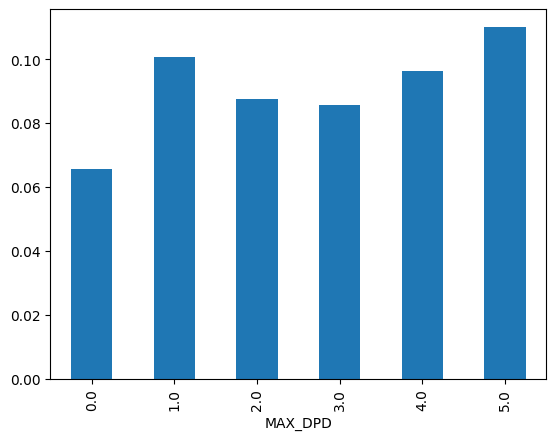

In [78]:
df.groupby(by=df['MAX_DPD'])['TARGET'].mean().plot(kind='bar')

As the MAX_DPD (Maximum Days Past Due) increases, the default rate also increases.This indicates that higher past-due behavior is strongly associated with a higher  default

#### BUREAU DATASET FEATURES

<Axes: xlabel='NUM_ACTIVE_CREDIT'>

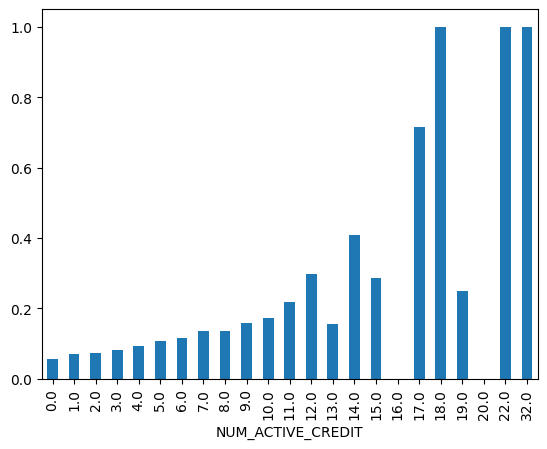

In [79]:
df.groupby(by=df['NUM_ACTIVE_CREDIT'])['TARGET'].mean().plot(kind='bar')

In [80]:
df['NUM_ACTIVE_CREDIT'].quantile(0.99)

np.float64(8.0)

* probability of default increses with the more active credit. that suggest managing multiple loans face higher credit stress.
* 99% of data have less values than the 8 so dues to less data avilability capping will improve the model performance

<Axes: xlabel='HAS_BAD_LOAN'>

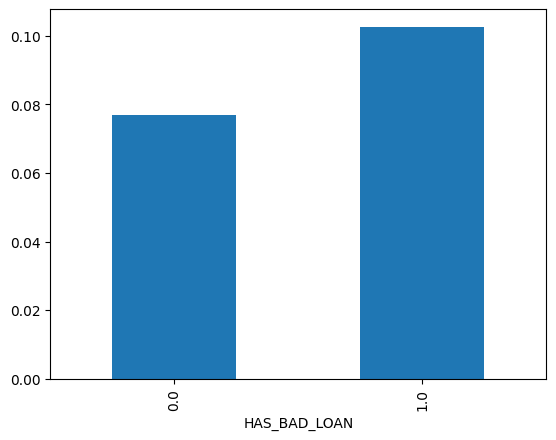

In [81]:
df.groupby(by=df['HAS_BAD_LOAN'])['TARGET'].mean().plot(kind='bar')

* the default rate is higher in the people who has bad loan in past compared to the people who hasn't

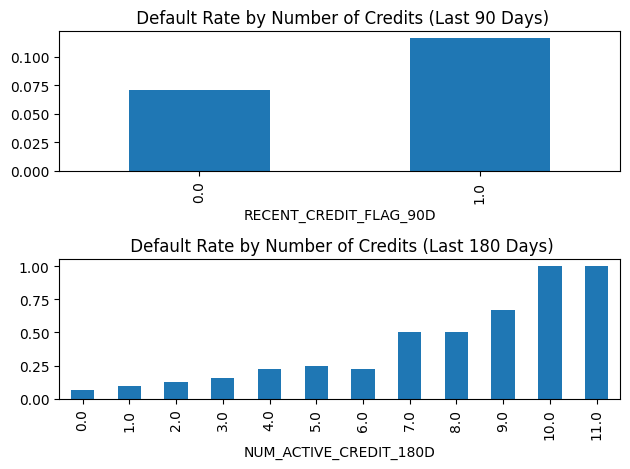

In [82]:
plt.subplot(2,1,1)

df.groupby(by=df['RECENT_CREDIT_FLAG_90D'])['TARGET'].mean().plot(
    kind='bar',title=' Default Rate by Number of Credits (Last 90 Days)')
plt.subplot(2,1,2)
df.groupby(by=df['NUM_ACTIVE_CREDIT_180D'])['TARGET'].mean().plot(
    kind='bar',title=' Default Rate by Number of Credits (Last 180 Days)')
plt.tight_layout()
plt.show()

In [83]:
df['NUM_ACTIVE_CREDIT_180D'].quantile(0.99)

np.float64(3.0)

* the credit risk increases with the higher number of active credit in last 180 days.the reason can be applicant have to manage multiple loans
* NUM_ACTIVE_CREDIT_180D in this feature the 99% observation have less value than 3 so we need to handle outlier using capping

In [84]:
df.groupby(by=df['HAS_CREDIT_DAYS_OVERDUE'])['TARGET'].mean() 

HAS_CREDIT_DAYS_OVERDUE
0.0    0.076234
1.0    0.158964
Name: TARGET, dtype: float64

<Axes: title={'center': ' Default Rate by Applicant has credit overdues in past'}, xlabel='HAS_CREDIT_DAYS_OVERDUE'>

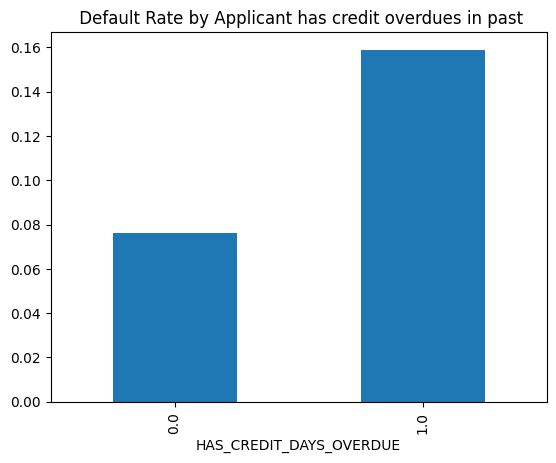

In [85]:
df.groupby(by=df['HAS_CREDIT_DAYS_OVERDUE'])['TARGET'].mean().plot(
    kind='bar',title=' Default Rate by Applicant has credit overdues in past')

* HAS_CREDIT_DAYS_OVERDUE feature have very strong relation with the credit risk.applicant who had the overdue in past have higher credit risk than who hadn't. the value=0 have the ~7 default rate and the value=1 have the ~15 default rate.

<Axes: title={'center': 'Default Rate by FLAG_HAS_AMT_OVERDUE '}, xlabel='FLAG_HAS_AMT_OVERDUE'>

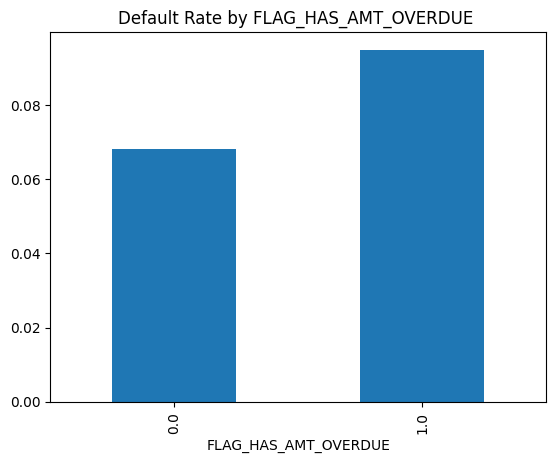

In [86]:
df.groupby(df['FLAG_HAS_AMT_OVERDUE'])['TARGET'].mean().plot(kind='bar',title='Default Rate by FLAG_HAS_AMT_OVERDUE ')

* the default rate is higher in the people who has FLAG_HAS_AMT_OVERDUE value = 1 in past compared to the people who hasn't value=0

<Axes: title={'center': 'Default Raate by FLAG_HAS_CREDIT_PROLONG '}, xlabel='FLAG_HAS_CREDIT_PROLONG'>

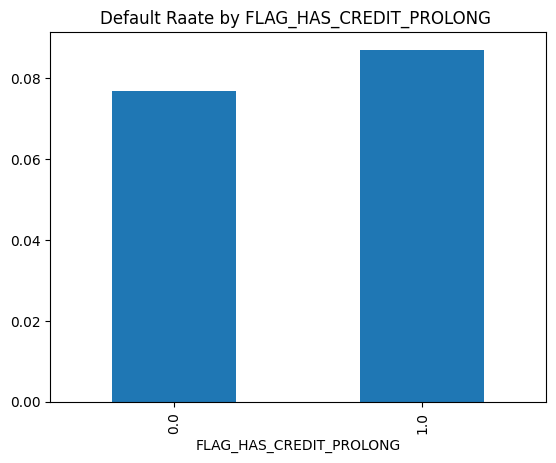

In [87]:
df.groupby(df['FLAG_HAS_CREDIT_PROLONG'])['TARGET'].mean().plot(kind='bar',title='Default Raate by FLAG_HAS_CREDIT_PROLONG ')

In [88]:
# winsomarization
lower = df['AVG_REPAYMENT_DAYS_DIFF'].quantile(0.01)
upper = df['AVG_REPAYMENT_DAYS_DIFF'].quantile(0.99)


df['DUMMY_AVG_REPAYMENT'] = df['AVG_REPAYMENT_DAYS_DIFF'].clip(lower,upper)

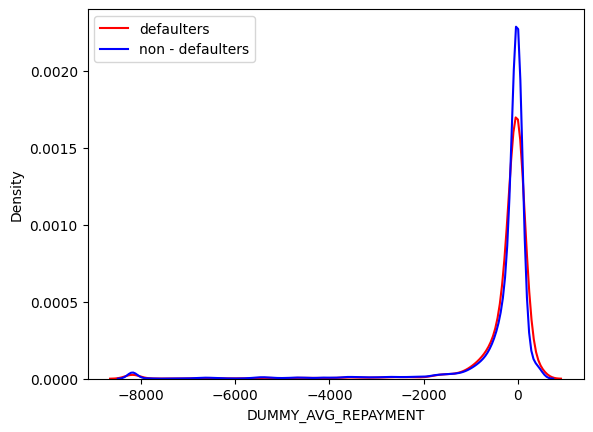

In [89]:
filt = df['TARGET'] == 1
sns.kdeplot(df.loc[filt,'DUMMY_AVG_REPAYMENT'],color='r',label='defaulters')
filt = df['TARGET'] == 0
sns.kdeplot(df.loc[filt,'DUMMY_AVG_REPAYMENT'],color='b',label='non - defaulters')
plt.legend()
plt.show()

* the feature is left skewed use transformation and check woe or iv then use only.
 doesnt shows any relation 

##### DEBT_TO_LOAN_RATIO

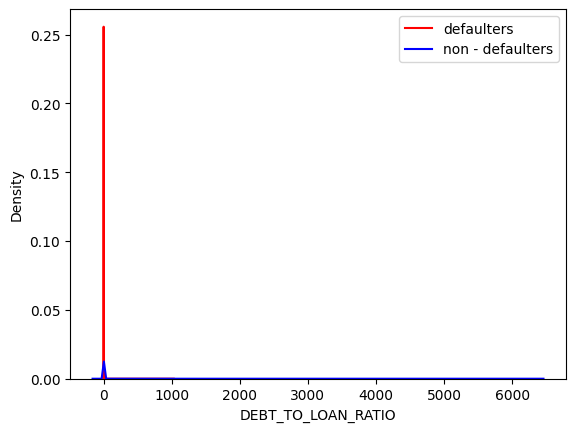

In [90]:
filt = df['TARGET'] == 1
sns.kdeplot(df.loc[filt,'DEBT_TO_LOAN_RATIO'],color='r',label='defaulters')
filt = df['TARGET'] == 0
sns.kdeplot(df.loc[filt,'DEBT_TO_LOAN_RATIO'],color='b',label='non - defaulters')
plt.legend()
plt.show()

In [91]:
lower = df['DEBT_TO_LOAN_RATIO'].quantile(0.01)
upper = df['DEBT_TO_LOAN_RATIO'].quantile(0.99)
df['DUMMY_DEBT_TO_LOAN_RATIO'] = df['DEBT_TO_LOAN_RATIO'].clip(lower,upper)

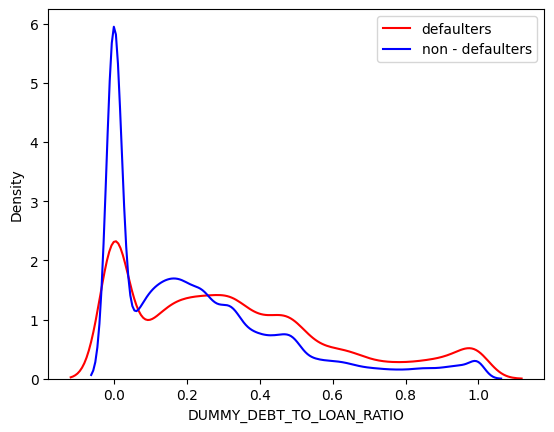

In [92]:
filt = df['TARGET'] == 1
sns.kdeplot(df.loc[filt,'DUMMY_DEBT_TO_LOAN_RATIO'],color='r',label='defaulters')
filt = df['TARGET'] == 0
sns.kdeplot(df.loc[filt,'DUMMY_DEBT_TO_LOAN_RATIO'],color='b',label='non - defaulters')
plt.legend()
plt.show()

* DEBT_TO_LOAN_RATIO needs outlier handling due to in bureau dataset there are some extreme values. 99% values are between 0-1 so the outliers needs to capped
* as the DEBT_TO_LOAN_RATIO  increases the probability of the default increases

In [93]:
lower = df['AVG_AMT_CREDIT_SUM'].quantile(0.01)
upper = df['AVG_AMT_CREDIT_SUM'].quantile(0.99)
df['DUMMY_AVG_AMT_CREDIT_SUM'] = df['AVG_AMT_CREDIT_SUM'].clip(lower,upper)

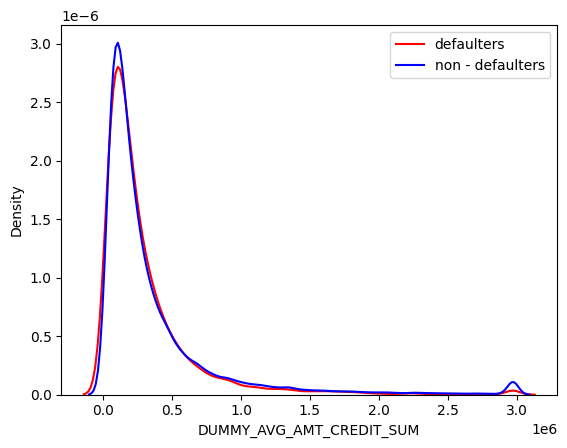

In [94]:
filt = df['TARGET'] == 1
sns.kdeplot(df.loc[filt,'DUMMY_AVG_AMT_CREDIT_SUM'],color='r',label='defaulters')
filt = df['TARGET'] == 0
sns.kdeplot(df.loc[filt,'DUMMY_AVG_AMT_CREDIT_SUM'],color='b',label='non - defaulters')
plt.legend()
plt.show()

* the distribution overlap almost completely. so this feature doesnt diffrentiate between good and bad borrowers so it might not add predictive power to the model

In [95]:
df.groupby(df['HAS_CREDIT_LOAN'])['TARGET'].mean()

HAS_CREDIT_LOAN
0.0    0.069853
1.0    0.081259
Name: TARGET, dtype: float64

<Axes: title={'center': 'HAS CREDIT LOAN'}, xlabel='HAS_CREDIT_LOAN'>

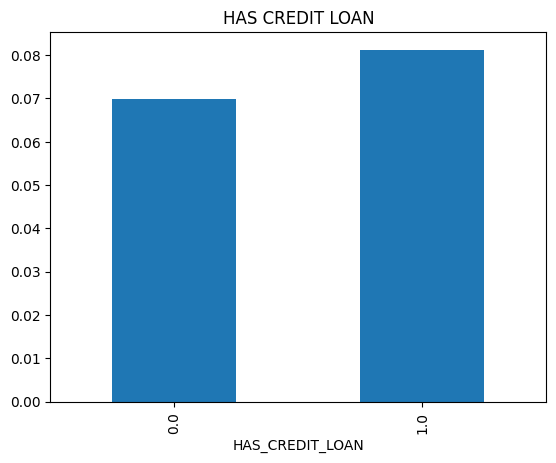

In [96]:
df.groupby(df['HAS_CREDIT_LOAN'])['TARGET'].mean().plot(kind='bar',title='HAS CREDIT LOAN')

* HAS_CREDIT_LOAN have weak relation with target variable. the difference between  Applicants who have a credit loan tend to default only about 1% more

#### INSTALLMENT PAYMENTS FEATURES

##### NUM_UNDERPAID_INSTALLMENTS_1Y

<Axes: xlabel='NUM_UNDERPAID_INSTALLMENTS_1Y'>

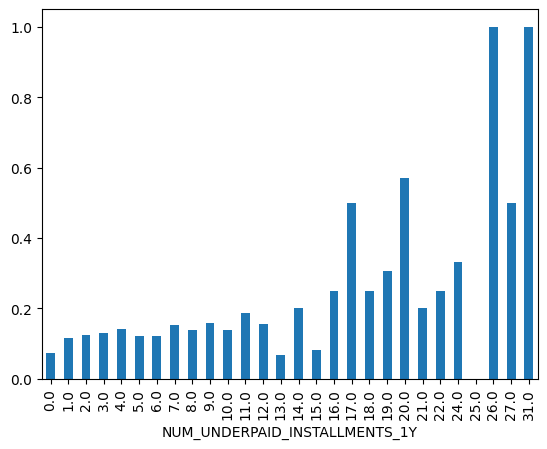

In [97]:
df.groupby(by=df['NUM_UNDERPAID_INSTALLMENTS_1Y'])['TARGET'].mean().plot(kind='bar')

In [98]:
df['DUMMY_NUM_UNDERPAID_INSTALLMENTS_1Y'] = np.where(df['NUM_UNDERPAID_INSTALLMENTS_1Y']>=6
                                                     ,6,df['NUM_UNDERPAID_INSTALLMENTS_1Y'])

In [99]:
df['NUM_UNDERPAID_INSTALLMENTS_1Y'].quantile(0.99)

np.float64(6.0)

<Axes: xlabel='DUMMY_NUM_UNDERPAID_INSTALLMENTS_1Y'>

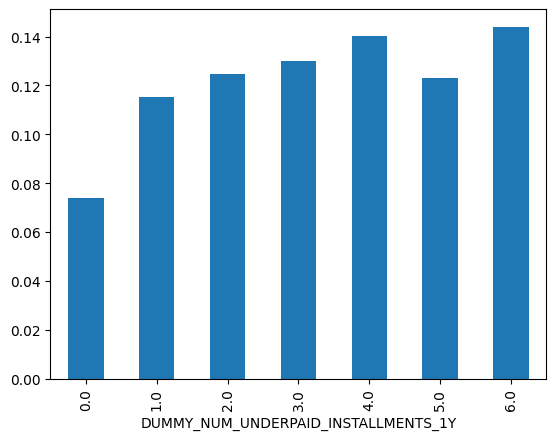

In [100]:
df.groupby(by=df['DUMMY_NUM_UNDERPAID_INSTALLMENTS_1Y'])['TARGET'].mean().plot(kind='bar')

* the NUM_UNDERPAID_INSTALLMENTS_1Y have 99% values less than 6. so larger values need to be capped.
* NUM_UNDERPAID_INSTALLMENTS_1Y have the upward trend suggesting the higher the num underpaid installments higher the credit risk

#### POS CASH DATASET FEATURE

##### HAS_RISKY_CONTRACT_STATUS

In [101]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,YEARS_AGE,YEARS_EMPLOYED,YEARS_REGISTRATION,YEARS_ID_PUBLISH,MAX_DPD,NUM_ACTIVE_CREDIT,HAS_BAD_LOAN,NUM_CLOSED_CREDIT,RECENT_CREDIT_FLAG_90D,NUM_ACTIVE_CREDIT_180D,HAS_CREDIT_DAYS_OVERDUE,AVG_REPAYMENT_DAYS_DIFF,FLAG_HAS_AMT_OVERDUE,FLAG_HAS_CREDIT_PROLONG,DEBT_TO_LOAN_RATIO,AVG_AMT_CREDIT_SUM,HAS_CREDIT_LOAN,NUMBER_OF_RESHEDULES_6M,SUM_DPD_RECENT_6M,MEAN_DPD_RECENT_2Y,NUM_UNDERPAID_INSTALLMENTS_1Y,HAS_RISKY_CONTRACT_STATUS,NUM_ACTIVE_LOANS_6M,NUM_ACTIVE_LOANS_1Y,TOTAL_REMAINING_INSTALLMENTS,FLAG_DPD_DEF_1Y,MEAN_DPD_1Y,AVG_AMT_ANNUITY_CLIENT,AVG_AMT_CREDIT_CLIENT,AVG_CREDIT_APPLICATION_RATIO,AVG_DOWN_PAYMENT_RATE,AVG_AMT_GOODS_PRICE,AVG_PRIVILEGED_RATE_FLAG,RATIO_REFUSED_LOANS,LOANS_REFUSED_RECENT_60D,LOANS_REFUSED_RECENT_180D,FLAG_HC_REJECT_REASON_2Y,NUM_SCO_SCOFR_REJECT_REASON,NUM_ALONE_APPLICATIONS,FLAG_REPEATER,FLAG_NEW_CLIENT,NUM_CASH_LOANS_RECENT_180D,NUM_HIGH_RISK_CHANNEL_METHOD,RATIO_INSURED_LOANS,RATIO_HIGH_RISK_YIELD_LOANS,MEAN_LOAN_REPAYMENT_DIFF,MAX_LOAN_REPAYMENT_DIFF,FLAG_OWN_CREDIT_CARD,MEAN_RATIO_CREDIT_UTILIZATION_DEBT_1M,CREDIT_USAGE_RATIO_12M_ACTIVE_MEAN,AVG_ATM_DRAWINGS_RECENT_6M,POS_SPEND_RATIO_MEAN_1Y,ATM_WITHDRAWAL_RATIO_MEAN_6M,AVG_LATEST_PAYMENT_COVERAGE_RATIO_6M,AVG_PAYMENT_COVERAGE_RATIO,AVG_PRINCIPAL_RATIO,AVG_TOTAL_RECEIVABLE_RATIO,AVG_INSTALLMENTS_PER_CUST,DUMMY_CHILDREN,DUMMY_FAM_MEMBERS,CNT_OTHER_DOCUMENT_PROVIDED,DUMMY_AMT_QTR,DUMMY_AMT_MON,DUMMY_AMT_YEAR,DUMMY_AVG_REPAYMENT,DUMMY_DEBT_TO_LOAN_RATIO,DUMMY_AVG_AMT_CREDIT_SUM,DUMMY_NUM_UNDERPAID_INSTALLMENTS_1Y
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary education,Single,Owned,0.018801,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,

<Axes: xlabel='HAS_RISKY_CONTRACT_STATUS'>

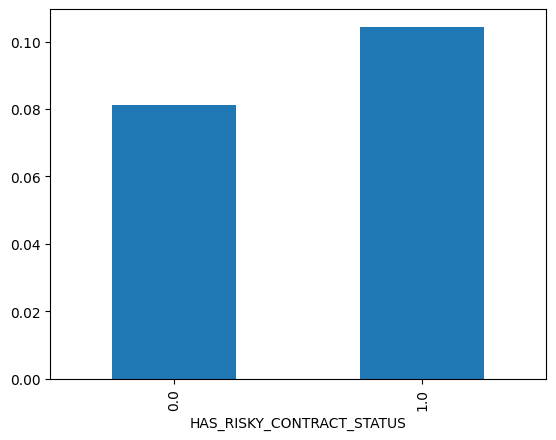

In [102]:
df.groupby(by=df['HAS_RISKY_CONTRACT_STATUS'])['TARGET'].mean().plot(kind='bar')

* the people who has risky contract status have slighlty higher default rate 

##### NUM_ACTIVE_LOANS_1Y

<Axes: xlabel='NUM_ACTIVE_LOANS_1Y'>

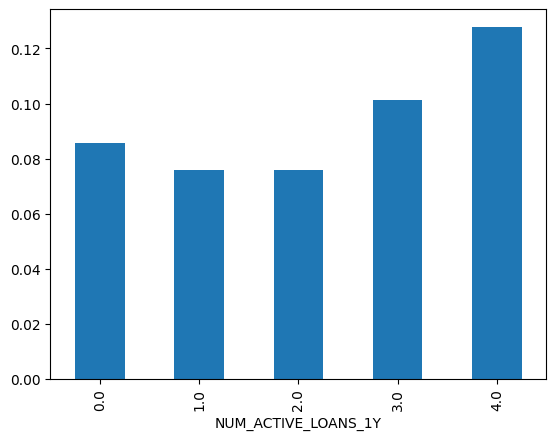

In [103]:
df.groupby(by=df['NUM_ACTIVE_LOANS_1Y'])['TARGET'].mean().plot(kind='bar')

* NUM_ACTIVE_LOANS_1Y doesnt have any extra information than NUM_ACTIVE_LOANS_6M so remove it
* NUM_ACTIVE_LOANS_1Y the default rate increases with the number of active loans increases in 1 year

In [104]:
df.groupby(by=df['FLAG_DPD_DEF_1Y'])['TARGET'].mean()

FLAG_DPD_DEF_1Y
0.0    0.079770
1.0    0.155724
Name: TARGET, dtype: float64

<Axes: xlabel='FLAG_DPD_DEF_1Y'>

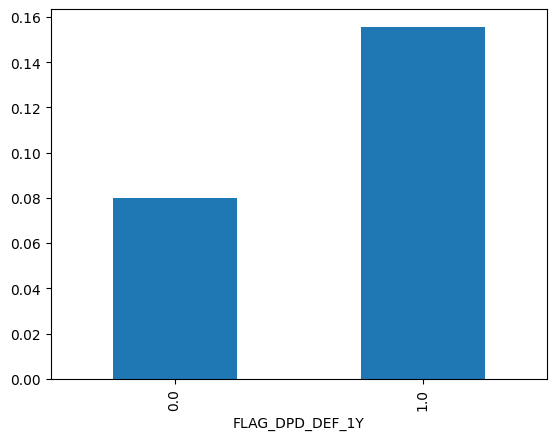

In [105]:
df.groupby(by=df['FLAG_DPD_DEF_1Y'])['TARGET'].mean().plot(kind='bar')

* The default rate among  applicants  FLAG_DPD_DEF_1Y who have DEF DPD flag is  ~15`% higher than  those who haven't i.e ~8%


* the distribution of SUM_DPD_RECENT_6M and MEAN_DPD_1Y overlap for good and bad borrowers . so this features doesnt seems to diffrentiate between good and bad borrowers so it might not add predictive power to the model
* both have right skewed distribution

In [106]:
df['TOTAL_REMAINING_INSTALLMENTS'].quantile(0.99)

np.float64(51.0)

In [107]:
df['DUMMY_TOTAL_REMAINING_INSTALLMENTS'] = np.where(df['TOTAL_REMAINING_INSTALLMENTS']>=51
                                                     ,51,df['TOTAL_REMAINING_INSTALLMENTS'])

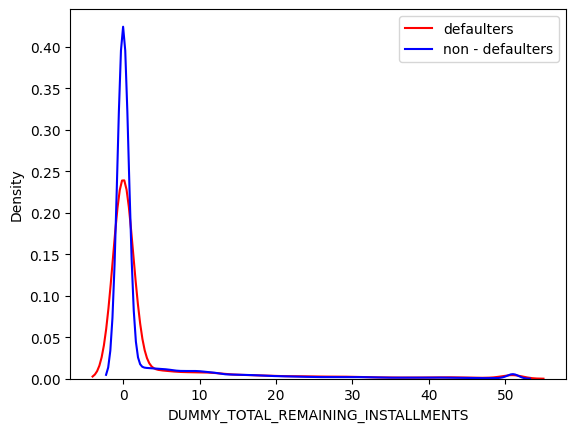

In [108]:
filt = df['TARGET'] == 1
sns.kdeplot(df.loc[filt,'DUMMY_TOTAL_REMAINING_INSTALLMENTS'],color='r',label='defaulters')
filt = df['TARGET'] == 0
sns.kdeplot(df.loc[filt,'DUMMY_TOTAL_REMAINING_INSTALLMENTS'],color='b',label='non - defaulters')
plt.legend()
plt.show()

TOTAL_REMAINING_INSTALLMENTS doesnt show any significant relation with  Target Variable and it is right skewed distribution

#### PREVIOUS APPLICATION FEATURES

In [109]:
def create_feature_target_plot(varible):
    filt = df['TARGET'] == 1
    sns.kdeplot(df.loc[filt,varible],color='r',label='defaulters')
    filt = df['TARGET'] == 0
    sns.kdeplot(df.loc[filt,varible],color='b',label='non - defaulters')
    plt.legend()


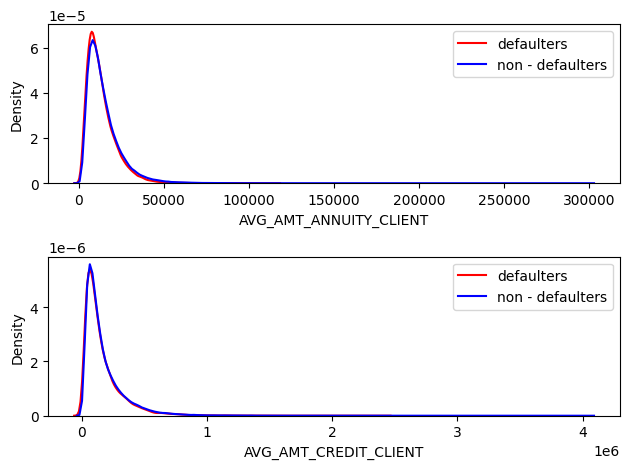

In [110]:
plt.subplot(2,1,1)
create_feature_target_plot('AVG_AMT_ANNUITY_CLIENT')
plt.subplot(2,1,2)
create_feature_target_plot('AVG_AMT_CREDIT_CLIENT')
plt.tight_layout()

* AVG_AMT_ANNUITY_CLIENT AVG_AMT_CREDIT_CLIENT both feature have  right skewed distribution both dont shows any significant relation with the target variable
* need to use transformation

In [111]:
df['AVG_CREDIT_APPLICATION_RATIO'].replace({np.inf:np.nan}).quantile(0.99)

np.float64(1.244670814813752)

In [112]:
df['DUMMY_AVG_CREDIT_APPLICATION_RATIO'] = np.where(df['AVG_CREDIT_APPLICATION_RATIO']>=1.24
                                                     ,1.24,df['AVG_CREDIT_APPLICATION_RATIO'])

<Axes: xlabel='DUMMY_AVG_CREDIT_APPLICATION_RATIO', ylabel='Density'>

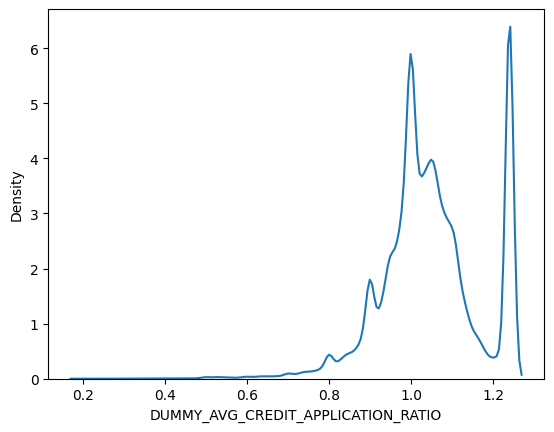

In [113]:
sns.kdeplot(df['DUMMY_AVG_CREDIT_APPLICATION_RATIO'])

* have  left skewed distribution and needs to handle outliers
* AVG_CREDIT_APPLICATION_RATIO feature contains inf values

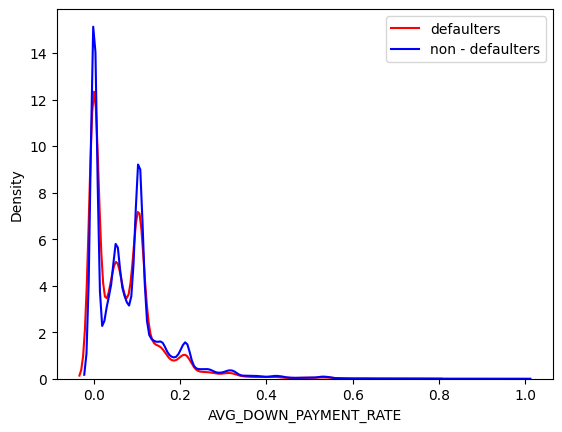

In [114]:
create_feature_target_plot('AVG_DOWN_PAYMENT_RATE')

* right skewed distribution dont seems to have strong relation with target variable
* most of the client on their previous loans paid the downpayment amount between 0 to 0.2% of the credit amount 

<Axes: xlabel='AVG_AMT_GOODS_PRICE', ylabel='Density'>

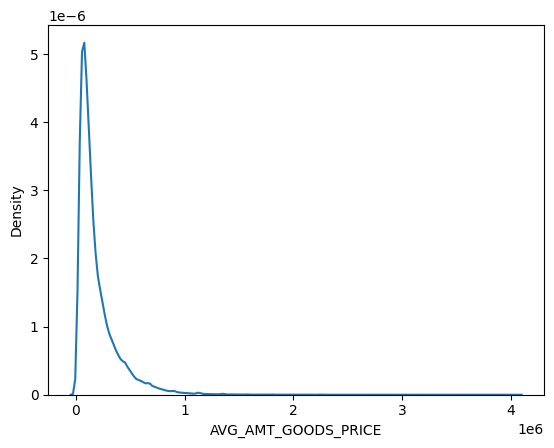

In [115]:
sns.kdeplot(df['AVG_AMT_GOODS_PRICE'])

In [116]:
upper = df['AVG_AMT_GOODS_PRICE'].quantile(0.99)
df['DUMYY_AVG_AMT_GOODS_PRICE'] = np.where(df['AVG_AMT_GOODS_PRICE']>= upper,upper,df['AVG_AMT_GOODS_PRICE'])

<Axes: xlabel='DUMYY_AVG_AMT_GOODS_PRICE', ylabel='Density'>

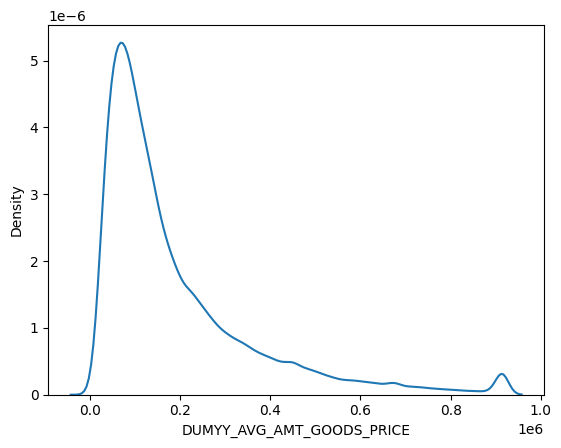

In [117]:
sns.kdeplot(df['DUMYY_AVG_AMT_GOODS_PRICE'])

* AVG_AMT_GOODS_PRICE variables needs outlier handling
* 99% values are less than  914618.49  in feature AVG_AMT_GOODS_PRICE
* even after capping the distribution is right skewed so use transformation

<Axes: xlabel='AVG_PRIVILEGED_RATE_FLAG', ylabel='Density'>

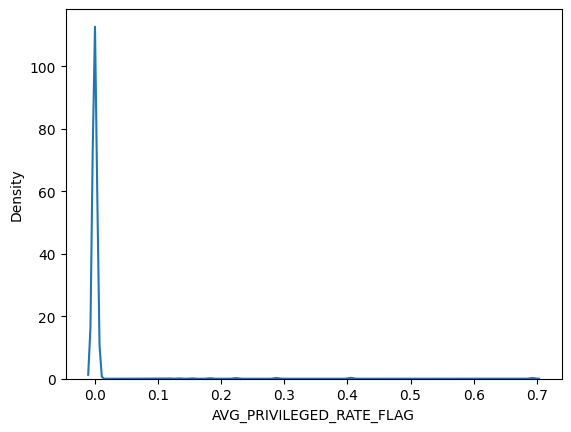

In [118]:
sns.kdeplot(np.log1p(df['AVG_PRIVILEGED_RATE_FLAG']))

AVG_PRIVILEGED_RATE_FLAG  has the right skewed distribution
outliers are present

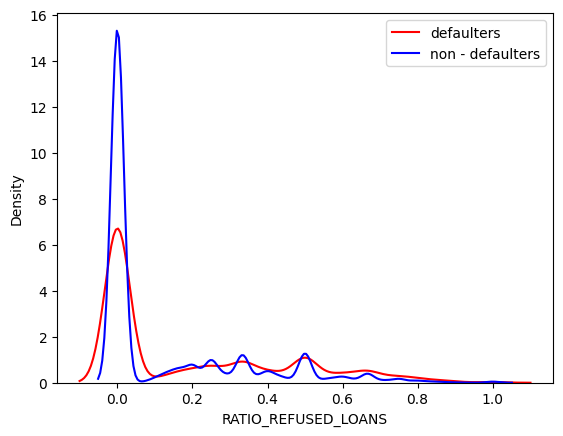

In [119]:
create_feature_target_plot('RATIO_REFUSED_LOANS')

* there are small patterns in RATIO_REFUSED_LOANS but overall distribution overlaps for default and non default
* right skewed distribution needs to use transformation

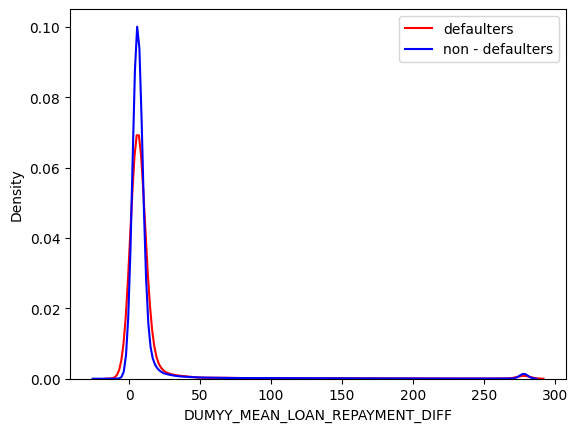

In [120]:
upper = df['MEAN_LOAN_REPAYMENT_DIFF'].quantile(0.99)
df['DUMYY_MEAN_LOAN_REPAYMENT_DIFF'] = np.where(df['MEAN_LOAN_REPAYMENT_DIFF']>= upper,upper,df['MEAN_LOAN_REPAYMENT_DIFF'])
create_feature_target_plot('DUMYY_MEAN_LOAN_REPAYMENT_DIFF')

* MAX_LOAN_REPAYMENT_DIFF , MEAN_LOAN_REPAYMENT_DIFF contains outlier  needs to handle by capping and have right skewed distribution 
* RATIO_HIGH_RISK_YIELD_LOANS  has right skewed distribution and also has outliers
* this all feature doesnt suggest any pattern with target variable still check woe or iv for this features

<Axes: xlabel='FLAG_HAS_LOAN_REFUSED_RECENT_6M'>

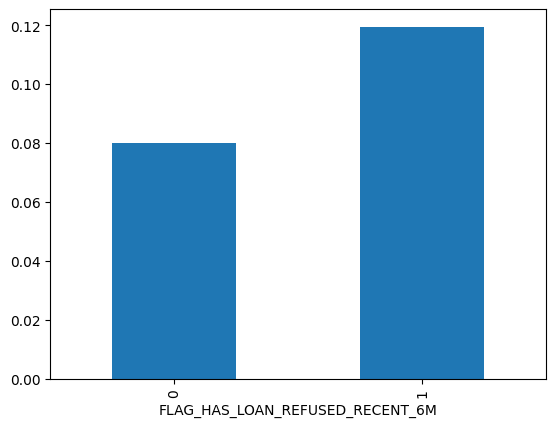

In [121]:
df['FLAG_HAS_LOAN_REFUSED_RECENT_6M'] = np.where(df['LOANS_REFUSED_RECENT_60D'] > 0,1,0)
df.groupby(df['FLAG_HAS_LOAN_REFUSED_RECENT_6M'])['TARGET'].mean().plot(kind='bar')

* LOANS_REFUSED_RECENT_60D	 dont use this feature since both feature provides same values
* LOANS_REFUSED_RECENT_180D create flag based on this feature that FLAG_HAS_LOAN_REFUSED_RECENT_6M it helps to differentiate between the defaulters and non defaulters
* the people who had the refused loan in last recent 6 months have higher default probability then the people who hadn't by ~4% even it is not big difference still there is pattern.

<Axes: xlabel='FLAG_HC_REJECT_REASON_2Y'>

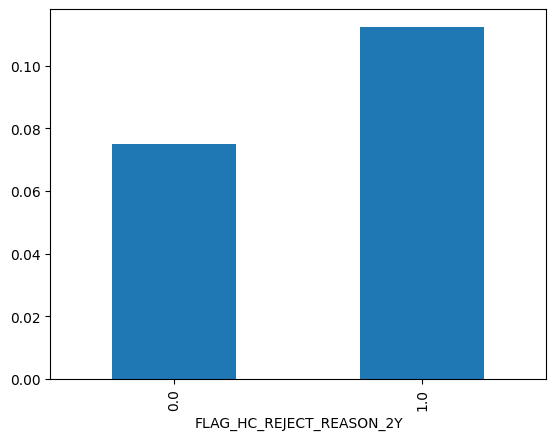

In [122]:
df.groupby(df['FLAG_HC_REJECT_REASON_2Y'])['TARGET'].mean().plot(kind='bar')

* the people who had the FLAG_HC_REJECT reason in last 2 year have higher default probability then the people who hadn't by ~4% even it is not big difference still there is pattern.

In [123]:
upper = df['NUM_SCO_SCOFR_REJECT_REASON'].quantile(0.999)
df['DUMMY_NUM_SCO_SCOFR_REJECT_REASON'] = np.where(df['NUM_SCO_SCOFR_REJECT_REASON'] > upper,upper,df['NUM_SCO_SCOFR_REJECT_REASON'])


<Axes: xlabel='DUMMY_NUM_SCO_SCOFR_REJECT_REASON'>

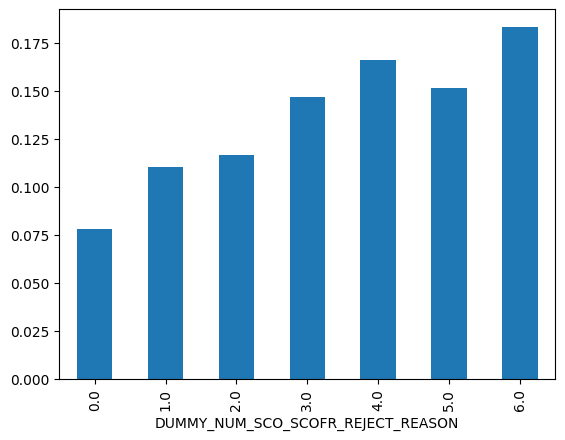

In [124]:
df.groupby(df['DUMMY_NUM_SCO_SCOFR_REJECT_REASON'])['TARGET'].mean().plot(kind='bar')

* NUM_SCO_SCOFR_REJECT_REASON has sparse distribution
* the more the  NUM_SCO_SCOFR_REJECT_REASON cnt the more default rate it have correlation
* NUM_SCO_SCOFR_REJECT_REASON capped this variable at 6 99.9% data is below the 6 and there are some extreme outliers so capp them

In [125]:
upper = df['NUM_ALONE_APPLICATIONS'].quantile(0.999)
df['DUMMY_NUM_ALONE_APPLICATIONS'] = np.where(df['NUM_ALONE_APPLICATIONS'] > upper,upper,df['NUM_ALONE_APPLICATIONS'])


<Axes: xlabel='DUMMY_NUM_ALONE_APPLICATIONS'>

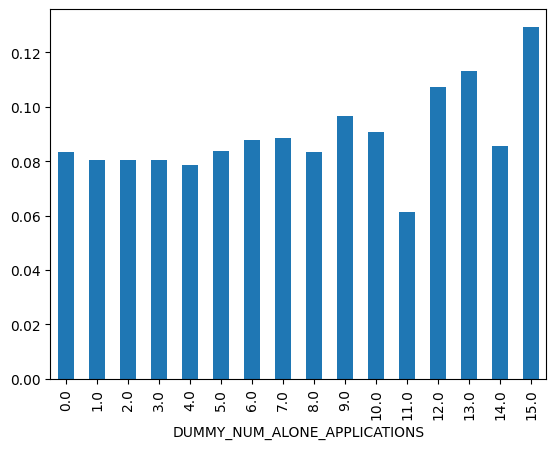

In [126]:
df.groupby(df['DUMMY_NUM_ALONE_APPLICATIONS'])['TARGET'].mean().plot(kind='bar')

* NUM_ALONE_APPLICATIONS dont suggest there is pattern with the target variable and it have right tailed distribution need to handle outliers

<Axes: xlabel='FLAG_NEW_CLIENT'>

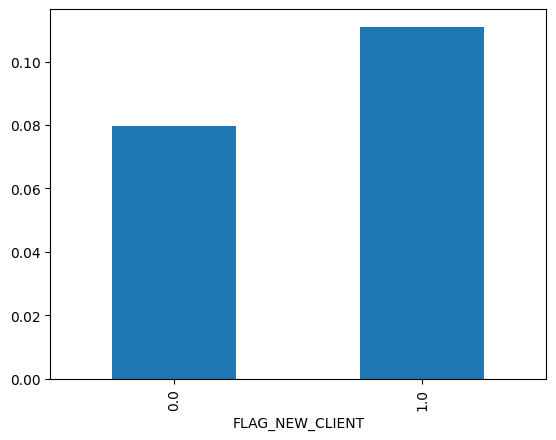

In [127]:
df.groupby(df['FLAG_NEW_CLIENT'])['TARGET'].mean().plot(kind='bar')

* the people who had applied for the first time they have  higher default probability then the people who is alredy customer by ~3% even it is not big difference still there is pattern.

FLAG_REPEATER,NUM_CASH_LOANS_RECENT_180D  dont have any relation with the target variable avoid using it

In [128]:
upper = df['NUM_HIGH_RISK_CHANNEL_METHOD'].quantile(0.99)
df['DUMMY_NUM_HIGH_RISK_CHANNEL_METHOD'] = np.where(df['NUM_HIGH_RISK_CHANNEL_METHOD'] > upper,upper,df['NUM_HIGH_RISK_CHANNEL_METHOD'])


<Axes: xlabel='DUMMY_NUM_HIGH_RISK_CHANNEL_METHOD'>

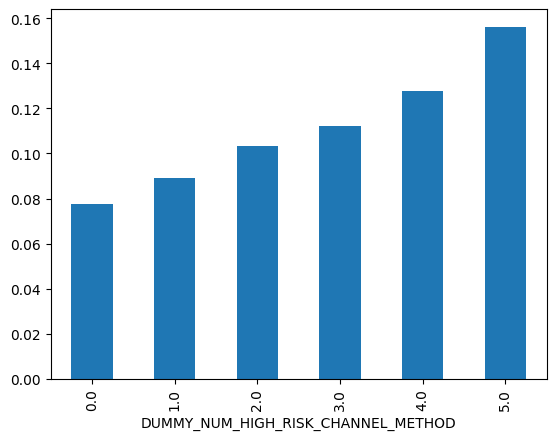

In [129]:
df.groupby(df['DUMMY_NUM_HIGH_RISK_CHANNEL_METHOD'])['TARGET'].mean().plot(kind='bar')

* feature NUM_HIGH_RISK_CHANNEL_METHOD have sparsed data 99% data is below the 5 values. so need to handle those extreme values
* the NUM_HIGH_RISK_CHANNEL_METHOD num increases the default rate increases that shows the realtion between those two features so. we can say that the people who had the high count of risk channel method for loan have higher probability of default

#### CREDIT CARD BALANCE FEATURES

In [135]:
df['FLAG_OWN_CREDIT_CARD'] = df['FLAG_OWN_CREDIT_CARD'].fillna(0)

FLAG_OWN_CREDIT_CARD needs to fill 0 in place of NaN values

In [136]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,YEARS_AGE,YEARS_EMPLOYED,YEARS_REGISTRATION,YEARS_ID_PUBLISH,MAX_DPD,NUM_ACTIVE_CREDIT,HAS_BAD_LOAN,NUM_CLOSED_CREDIT,RECENT_CREDIT_FLAG_90D,NUM_ACTIVE_CREDIT_180D,HAS_CREDIT_DAYS_OVERDUE,AVG_REPAYMENT_DAYS_DIFF,FLAG_HAS_AMT_OVERDUE,FLAG_HAS_CREDIT_PROLONG,DEBT_TO_LOAN_RATIO,AVG_AMT_CREDIT_SUM,HAS_CREDIT_LOAN,NUMBER_OF_RESHEDULES_6M,SUM_DPD_RECENT_6M,MEAN_DPD_RECENT_2Y,NUM_UNDERPAID_INSTALLMENTS_1Y,HAS_RISKY_CONTRACT_STATUS,NUM_ACTIVE_LOANS_6M,NUM_ACTIVE_LOANS_1Y,TOTAL_REMAINING_INSTALLMENTS,FLAG_DPD_DEF_1Y,MEAN_DPD_1Y,AVG_AMT_ANNUITY_CLIENT,AVG_AMT_CREDIT_CLIENT,AVG_CREDIT_APPLICATION_RATIO,AVG_DOWN_PAYMENT_RATE,AVG_AMT_GOODS_PRICE,AVG_PRIVILEGED_RATE_FLAG,RATIO_REFUSED_LOANS,LOANS_REFUSED_RECENT_60D,LOANS_REFUSED_RECENT_180D,FLAG_HC_REJECT_REASON_2Y,NUM_SCO_SCOFR_REJECT_REASON,NUM_ALONE_APPLICATIONS,FLAG_REPEATER,FLAG_NEW_CLIENT,NUM_CASH_LOANS_RECENT_180D,NUM_HIGH_RISK_CHANNEL_METHOD,RATIO_INSURED_LOANS,RATIO_HIGH_RISK_YIELD_LOANS,MEAN_LOAN_REPAYMENT_DIFF,MAX_LOAN_REPAYMENT_DIFF,FLAG_OWN_CREDIT_CARD,MEAN_RATIO_CREDIT_UTILIZATION_DEBT_1M,CREDIT_USAGE_RATIO_12M_ACTIVE_MEAN,AVG_ATM_DRAWINGS_RECENT_6M,POS_SPEND_RATIO_MEAN_1Y,ATM_WITHDRAWAL_RATIO_MEAN_6M,AVG_LATEST_PAYMENT_COVERAGE_RATIO_6M,AVG_PAYMENT_COVERAGE_RATIO,AVG_PRINCIPAL_RATIO,AVG_TOTAL_RECEIVABLE_RATIO,AVG_INSTALLMENTS_PER_CUST,DUMMY_CHILDREN,DUMMY_FAM_MEMBERS,CNT_OTHER_DOCUMENT_PROVIDED,DUMMY_AMT_QTR,DUMMY_AMT_MON,DUMMY_AMT_YEAR,DUMMY_AVG_REPAYMENT,DUMMY_DEBT_TO_LOAN_RATIO,DUMMY_AVG_AMT_CREDIT_SUM,DUMMY_NUM_UNDERPAID_INSTALLMENTS_1Y,DUMMY_TOTAL_REMAINING_INSTALLMENTS,DUMMY_AVG_CREDIT_APPLICATION_RATIO,DUMYY_AVG_AMT_GOODS_PRICE,DUMYY_MEAN_LOAN_REPAYMENT_DIFF,FLAG_HAS_LOAN_REFUSED_RECENT_6M,DUMMY_NUM_SCO_SCOFR_REJECT_REASON,DUMMY_NUM_ALONE_APPLICATIONS,DUMMY_NUM_HIGH_RISK_CHANNEL_METHOD
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Work

<Axes: xlabel='FLAG_OWN_CREDIT_CARD'>

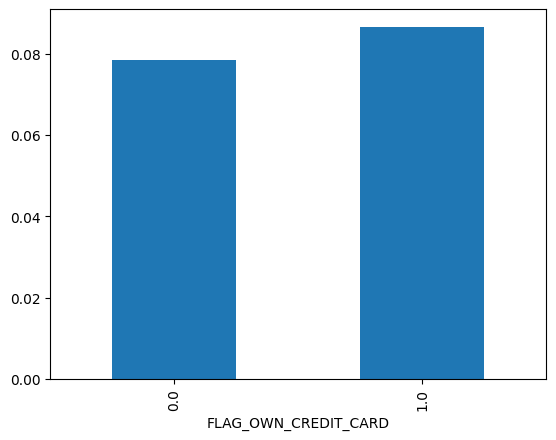

In [138]:
df.groupby(df['FLAG_OWN_CREDIT_CARD'])['TARGET'].mean().plot(kind='bar')

In [139]:
feature = ["MEAN_RATIO_CREDIT_UTILIZATION_DEBT_1M",
"CREDIT_USAGE_RATIO_12M_ACTIVE_MEAN",
"AVG_ATM_DRAWINGS_RECENT_6M",
"POS_SPEND_RATIO_MEAN_1Y",
"ATM_WITHDRAWAL_RATIO_MEAN_6M",
"AVG_LATEST_PAYMENT_COVERAGE_RATIO_6M",
"AVG_PAYMENT_COVERAGE_RATIO",
"AVG_PRINCIPAL_RATIO",
"AVG_TOTAL_RECEIVABLE_RATIO",
"AVG_INSTALLMENTS_PER_CUST",]

In [140]:
df[feature].isnull().sum() / df[feature].shape[0]

MEAN_RATIO_CREDIT_UTILIZATION_DEBT_1M    0.753914
CREDIT_USAGE_RATIO_12M_ACTIVE_MEAN       0.717392
AVG_ATM_DRAWINGS_RECENT_6M               0.801178
POS_SPEND_RATIO_MEAN_1Y                  0.841742
ATM_WITHDRAWAL_RATIO_MEAN_6M             0.717392
AVG_LATEST_PAYMENT_COVERAGE_RATIO_6M     0.888778
AVG_PAYMENT_COVERAGE_RATIO               0.807262
AVG_PRINCIPAL_RATIO                      0.720218
AVG_TOTAL_RECEIVABLE_RATIO               0.720218
AVG_INSTALLMENTS_PER_CUST                0.717392
dtype: float64

* all of this feature have the ~75% null values. due to those applicants dosen't have any credit card activity in home credit 
* filling those featuers values with 0 seems accurate but need to make sure that is not adding bias to data

In [149]:
upper = df['AVG_LATEST_PAYMENT_COVERAGE_RATIO_6M'].quantile(0.99)

np.float64(1235.9271682816227)

In [150]:
upper = df['AVG_LATEST_PAYMENT_COVERAGE_RATIO_6M'].quantile(0.99)
df['DUMMY_AVG_LATEST_PAYMENT_COVERAGE_RATIO_6M'] = np.where(df['AVG_LATEST_PAYMENT_COVERAGE_RATIO_6M'] > upper,upper,df['AVG_LATEST_PAYMENT_COVERAGE_RATIO_6M'])


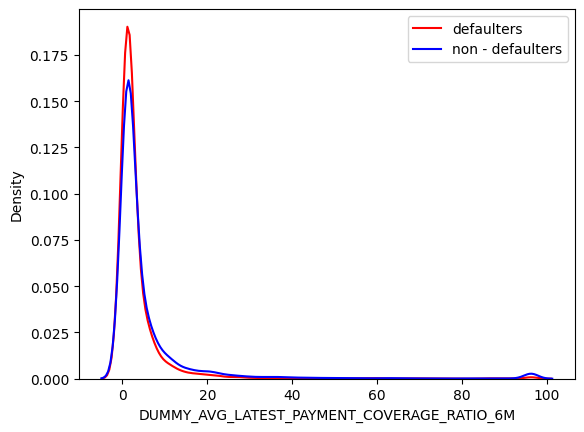

In [151]:
create_feature_target_plot('DUMMY_AVG_LATEST_PAYMENT_COVERAGE_RATIO_6M')

AVG_LATEST_PAYMENT_COVERAGE_RATIO_6M, AVG_PAYMENT_COVERAGE_RATIO has extreme outliers need to cap themm 
 and this variable have the right skewed distribution

In [ ]:
"AVG_PRINCIPAL_RATIO",
"AVG_TOTAL_RECEIVABLE_RATIO",
"AVG_INSTALLMENTS_PER_CUST",

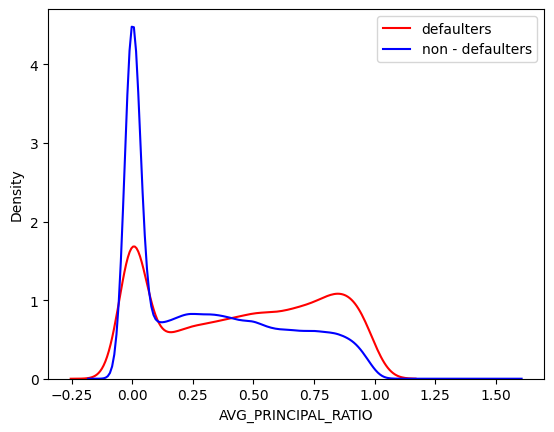

In [161]:
create_feature_target_plot('AVG_PRINCIPAL_RATIO')

* AVG_PRINCIPAL_RATIO right skewed distribution with most of the applicants clustered near 0.
* AVG_PRINCIPAL_RATIO the default rate in the applicants with higher principal ratio than 0.5% have higher default rate and credit risk
* the people who use more amount of principal tends to default more.

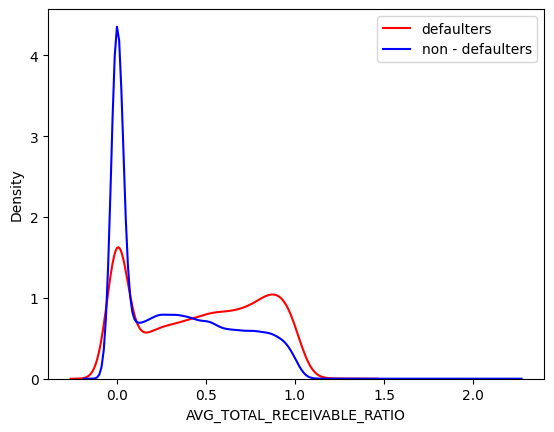

In [163]:
create_feature_target_plot('AVG_TOTAL_RECEIVABLE_RATIO')

* AVG_TOTAL_RECEIVABLE_RATIO the default rate in the applicants with higher principal ratio than 0.5% have higher default rate and credit risk
* this feature have similar distribution as AVG_PRINCIPAL_RATIO  due to total receivable amount means just a principle+interest+fees
* the people who uses more amount from credit (total_receivable) tends to default more.